### Imports and Funks

In [102]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.cm as cm
from mpl_toolkits import mplot3d
from typing import List, Optional, Union

# for creating a responsive plot 
%matplotlib widget 
  
# importing required libraries 
from mpl_toolkits.mplot3d import Axes3D 

import pandas as pd
from ipywidgets import interact, IntSlider

file_c3d_ON = uproot.open("histo_ON_c3d.root")
cmap = plt.get_cmap('viridis')

np.set_printoptions(precision=2, suppress=True, floatmode='fixed')
# np.set_printoptions()

In [506]:
file_c3d_ON.keys()

['ticlDumper;1',
 'ticlDumper/clusters;2',
 'ticlDumper/clusters;1',
 'ticlDumper/simtrackstersSC;2',
 'ticlDumper/simtrackstersSC;1',
 'ticlDumper/simtrackstersCP;2',
 'ticlDumper/simtrackstersCP;1',
 'ticlDumper/ticlTrackstersCLUE3DHigh;1',
 'ticlDumper/ticlTracksterLinks;1',
 'ticlDumper/ticlCandidate;1',
 'ticlDumper/ticlTracksterLinksSuperclusteringDNN;1',
 'ticlDumper/candidates;1',
 'ticlDumper/associations;1',
 'ticlDumper/tracks;1',
 'ticlDumper/simTICLCandidate;1']

##### Generals funks

In [2]:
def eta(x_arr, y_arr, z_arr):
    theta = np.arctan(np.sqrt(x_arr**2 + y_arr**2)/z_arr)
    return -np.log(np.tan(theta/2))

def eta_vec(arr):
    x, y, z = arr[:, 0], arr[:, 1], arr[:, 2]
    theta = np.arctan(np.sqrt(x**2 + y**2) / z)
    return -np.log(np.tan(theta / 2))

def theta_to_eta(theta):
    return -np.log(np.tan(theta/2))

def eta_to_theta(eta, degree = False):
    if degree == False:
        return np.arctan(np.exp(-eta))*2
    else:
        return np.arctan(np.exp(-eta))*2*180/np.pi

def phi(x_arr, y_arr):
    phi_angle = np.arctan(y_arr/x_arr)

    phi_angle = np.where([a and b for a, b in zip(x_arr<0, y_arr>0)],  phi_angle + np.pi, phi_angle)
    phi_angle = np.where([a and b for a, b in zip(x_arr<0, y_arr<0)],  phi_angle - np.pi, phi_angle)
    
    return phi_angle

def phi_diff(phi1, phi2, find_absolute = False):
    if find_absolute:
        abs_diff = np.abs(phi1 - phi2)
    else:
        abs_diff = phi1 - phi2
    abs_diff = np.where([a for a in abs_diff > np.pi ],  2*np.pi - abs_diff, abs_diff)
    abs_diff = np.where([a for a in abs_diff < -np.pi ],  2*np.pi + abs_diff, abs_diff)
    return abs_diff

##### PCA funks

In [3]:
class LayerClusters:
    """Represents layer clusters with 3D positions, energies, cluster_type, cluster_n_hits"""
    def __init__(self, x: Union[float, List], y: Union[float, List], z: Union[float, List], 
                 energy: Union[float, List], cluster_type = "default", 
                 cluster_n_hits= "default"):
        # Flatten all inputs to handle nested structures
        self.x_values = ak.flatten(x) 
        self.y_values = ak.flatten(y) 
        self.z_values = ak.flatten(z) 
        self.energy_values = ak.flatten(energy)         
        # Handle cluster types
        if isinstance(cluster_type, str):
            self.cluster_type = ["default"] * len(ak.flatten(x))
        else:
            self.cluster_type = cluster_type
        # Handle cluster_n_hits 
        if isinstance(cluster_n_hits, str):
            self.cluster_n_hits = ["default"] * len(ak.flatten(x))
        else:
            self.cluster_n_hits = cluster_n_hits
            
        # Validating that all arrays have the same length
        lengths = [len(self.x_values), len(self.y_values), len(self.z_values), 
                  len(self.energy_values), len(self.cluster_n_hits), len(self.cluster_type)]
        if not all(l == lengths[0] for l in lengths):
            raise ValueError(f"All input arrays must have the same length. Got lengths: {lengths}")
        
        self.n_clusters = len(self.x_values)
    
    def get_cluster(self, index: int):
        """Get individual cluster data by index"""
        if index >= self.n_clusters:
            raise IndexError(f"Index {index} out of range for {self.n_clusters} clusters")
        return {
            'x': self.x_values[index],
            'y': self.y_values[index], 
            'z': self.z_values[index],
            'energy': self.energy_values[index],
            'cluster_type': self.cluster_type[index],
            'cluster_n_hits': self.cluster_n_hits[index]
        }

class Vector3D:
    """Defines 3D vector class"""
    def __init__(self, x: float = 0.0, y: float = 0.0, z: float = 0.0):
        self.x = x
        self.y = y
        self.z = z

class Trackster:
    """Represents a trackster with vertices, energy, and PCA properties"""
    def __init__(self):
        self._vertices = []
        self._NCLusters_for_PCA = 0
        self._raw_energy = 0.0
        self._raw_em_energy = 0.0
        self._barycenter = Vector3D()
        self._eigenvalues = np.zeros(3)
        self._eigenvectors = np.zeros((3, 3))
    
    def get_vertices(self, i: Optional[int] = None):
        if i is None:
            return self._vertices
        return self._vertices[i]
    
    def set_barycenter(self, barycenter: Vector3D):
        self._barycenter = barycenter
    
    def fill_pca_variables(self, eigenvalues: np.ndarray, eigenvectors: np.ndarray):
        # Sort eigenvalues and eigenvectors in ascending order
        idx = np.argsort(eigenvalues)
        self._eigenvalues = eigenvalues[idx]
        self._eigenvectors = eigenvectors[:, idx]

def should_not_mask_cluster(clstr_type_arr , n_hits_arr) -> list:
    """
    Determine if a cluster should be masked based on cluster_n_hits and cluster_type.
    Masking rule: Mask LayerClusters with cluster_n_hits == 1 for all cluster_types 
    EXCEPT when cluster_type == 6.
    """
    mask = ((layer_clusters[0].cluster_n_hits == 1) & (layer_clusters[0].cluster_type !=6))
    
    return ~mask

def assign_pca_to_tracksters(tracksters: List[Trackster],
                            layer_clusters: [LayerClusters],
                            masking: bool = False , 
                            z_limit_em: float = 362.1,
                            energy_weight: bool = True) -> None:
    
    for trackster in tracksters:
        N = len(trackster.get_vertices())
        
        if N == 0:
            continue
        
        # Helper function to process cluster (handle multiple sub-clusters)
        def process_cluster(i):
            cluster_data = layer_clusters[0].get_cluster(i)
            energy = cluster_data['energy']
            pos = np.array([cluster_data['x'], cluster_data['y'], cluster_data['z']])
            return energy, pos
            
        # Filter out masked clusters
        if masking == True:
            if layer_clusters[0].get_cluster(0)['cluster_type'] == "default":
                raise ValueError(f"Masking True but cluser_types not defined properly")
            valid_indices = ak.where(should_not_mask_cluster(layer_clusters[0].cluster_type , layer_clusters[0].cluster_n_hits) == True)[0]
        else:
            valid_indices = range(N)
        
        trackster._NCLusters_for_PCA = len(valid_indices)
        
        # Skip if no valid clusters remain
        if len(valid_indices) == 0:
            trackster._raw_energy = 0.0
            trackster._raw_em_energy = 0.0
            trackster.set_barycenter(Vector3D(0.0, 0.0, 0.0))
            trackster.fill_pca_variables(np.zeros(3), np.eye(3))
            continue
        
        # Calculate energies and barycenter using ONLY valid (non-masked) clusters
        barycenter = np.zeros(3)
        total_energy = 0.0
        total_em_energy = 0.0
        total_weight = 0.0
        
        for i in valid_indices:
            cluster_energy, cluster_pos = process_cluster(i)
            
            total_energy += cluster_energy
            if abs(cluster_pos[2]) <= z_limit_em:
                total_em_energy += cluster_energy
            
            # Compute weighted barycenter
            if energy_weight:
                weight = cluster_energy
            else:
                weight = 1.0
            
            barycenter += weight * cluster_pos
            total_weight += weight
        
        # Normalize barycenter
        barycenter /= total_weight
        
        trackster._raw_energy = total_energy
        trackster._raw_em_energy = total_em_energy
        trackster.set_barycenter(Vector3D(barycenter[0], barycenter[1], barycenter[2]))
        
        # PCA computation (only for clusters with more than 2 valid hits)
        if len(valid_indices) > 2:
            cov_matrix = np.zeros((3, 3))
            weights2_sum = 0.0
            
            # Computing covariance matrix using only valid clusters
            for i in valid_indices:
                cluster_energy, cluster_pos = process_cluster(i)
                
                if energy_weight:
                    weight = cluster_energy / total_energy
                else:
                    weight = 1.0 / len(valid_indices)
                
                weights2_sum += weight * weight
                diff = cluster_pos - barycenter
                cov_matrix += weight * np.outer(diff, diff)
            
            # Normalize covariance matrix
            cov_matrix /= (1.0 - weights2_sum)
            
            # Perform eigendecomposition
            try:
                eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
                trackster.fill_pca_variables(eigenvalues, eigenvectors)
                
            except np.linalg.LinAlgError:
                # Set default values if eigendecomposition fails
                trackster.fill_pca_variables(np.zeros(3), np.eye(3))
        else:
            # Not enough clusters for PCA
            trackster.fill_pca_variables(np.zeros(3), np.eye(3))

## Initialise

### info

In [762]:
# General values
cluster_n_hits= file_c3d_ON["ticlDumper/clusters"].arrays(["cluster_number_of_hits" ], library= "ak")['cluster_number_of_hits']
cluster_type = file_c3d_ON["ticlDumper/clusters"].arrays(["cluster_type" ], library= "ak")['cluster_type']
c3dh_simToReco_SC_score = file_c3d_ON["ticlDumper/associations"].arrays(["ticlTrackstersCLUE3DHigh_simToReco_SC_score" ], library= "ak")["ticlTrackstersCLUE3DHigh_simToReco_SC_score"][:,0]
c3dh_simToReco_SC = file_c3d_ON["ticlDumper/associations"].arrays(["ticlTrackstersCLUE3DHigh_simToReco_SC" ], library= "ak")["ticlTrackstersCLUE3DHigh_simToReco_SC"][:,0]
tc_simToReco_SC_score = file_c3d_ON["ticlDumper/associations"].arrays(["ticlCandidate_simToReco_SC_score" ], library= "ak")["ticlCandidate_simToReco_SC_score"][:,0]
tc_simToReco_SC = file_c3d_ON["ticlDumper/associations"].arrays(["ticlCandidate_simToReco_SC" ], library= "ak")["ticlCandidate_simToReco_SC"][:,0]

In [763]:
#SimTracksterSC

vertices_indexes_SC_ON = file_c3d_ON["ticlDumper/simtrackstersSC"].arrays(["vertices_indexes" ], library= "ak")["vertices_indexes"]

coord_arr_SC_ON = file_c3d_ON["ticlDumper/simtrackstersSC"].arrays(["vertices_x", "vertices_y", "vertices_z" ], library= "ak")
energy_arr_SC_ON = file_c3d_ON["ticlDumper/simtrackstersSC"].arrays(["vertices_energy" ], library= "ak")
barycenters_SC_ON = file_c3d_ON["ticlDumper/simtrackstersSC"].arrays(["barycenter_x", "barycenter_y" , "barycenter_z"], library= "ak")
eVector0_SC_ON = file_c3d_ON["ticlDumper/simtrackstersSC"].arrays(["eVector0_x", "eVector0_y" , "eVector0_z", "sigmaPCA1", "sigmaPCA2", "sigmaPCA3"], library= "ak")
boundary_SC_ON = file_c3d_ON["ticlDumper/simtrackstersSC"].arrays(["boundaryX", "boundaryY" , "boundaryZ", "boundaryEta", "boundaryPhi"], library= "ak")
boundaryP_SC_ON = file_c3d_ON["ticlDumper/simtrackstersSC"].arrays(["boundaryPx", "boundaryPy" , "boundaryPz"], library= "ak")

barycenters_eta_SC_ON = file_c3d_ON["ticlDumper/simtrackstersSC"].arrays(["barycenter_eta"], library= "ak")["barycenter_eta"]
barycenters_phi_SC_ON = file_c3d_ON["ticlDumper/simtrackstersSC"].arrays(["barycenter_phi"], library= "ak")["barycenter_phi"]

NClusters_SC_ON = file_c3d_ON["ticlDumper/simtrackstersSC"].arrays(["NClusters"], library= "ak")["NClusters"]
EV_SC_ON = file_c3d_ON["ticlDumper/simtrackstersSC"].arrays(["EV1", "EV2", "EV3"], library= "ak")

# Hits
x_SC_ON , y_SC_ON , z_SC_ON = coord_arr_SC_ON["vertices_x"][:] , coord_arr_SC_ON["vertices_y"][:] , coord_arr_SC_ON["vertices_z"][:] 

# Energy
energy_SC_ON = energy_arr_SC_ON["vertices_energy"][:]
baryenergy_SC_ON = file_c3d_ON["ticlDumper/simtrackstersSC"].arrays(["raw_energy", "regressed_energy"],library = "ak")
baryenergy_raw_SC_ON = baryenergy_SC_ON["raw_energy"]
# baryenergy_reg_SC_ON = baryenergy_SC_ON["regressed_energy"]

# Barycenter
bary_z_SC_ON = barycenters_SC_ON["barycenter_z"]
bary_x_SC_ON = barycenters_SC_ON["barycenter_x"]
bary_y_SC_ON = barycenters_SC_ON["barycenter_y"]

# eVector
evector_x_SC_ON , evector_y_SC_ON , evector_z_SC_ON = eVector0_SC_ON["eVector0_x"] , eVector0_SC_ON["eVector0_y"] , eVector0_SC_ON["eVector0_z"]
evector_PCA1_SC_ON , evector_PCA2_SC_ON , evector_PCA3_SC_ON = eVector0_SC_ON["sigmaPCA1"] , eVector0_SC_ON["sigmaPCA2"] , eVector0_SC_ON["sigmaPCA3"]

# First Hit
boundaryX_SC_ON , boundaryY_SC_ON , boundaryZ_SC_ON = boundary_SC_ON["boundaryX"] , boundary_SC_ON["boundaryY"] , boundary_SC_ON["boundaryZ"]
boundaryEta_SC_ON , boundaryPhi_SC_ON = boundary_SC_ON["boundaryEta"] , boundary_SC_ON["boundaryPhi"]

boundaryPx_SC_ON , boundaryPy_SC_ON , boundaryPz_SC_ON = boundaryP_SC_ON["boundaryPx"] , boundaryP_SC_ON["boundaryPy"] , boundaryP_SC_ON["boundaryPz"]

In [764]:
# ticlTrackstersCLUE3DHigh               TiclCandidate Not yet (trackstersTiclCandidate)

vertices_indexes_tc3d_ON = file_c3d_ON["ticlDumper/ticlTrackstersCLUE3DHigh"].arrays(["vertices_indexes" ], library= "ak")["vertices_indexes"]

NClusters_tc3d_ON = file_c3d_ON["ticlDumper/ticlTrackstersCLUE3DHigh"].arrays(["NClusters"], library= "ak")["NClusters"]
EV_tc3d_ON = file_c3d_ON["ticlDumper/ticlTrackstersCLUE3DHigh"].arrays(["EV1", "EV2", "EV3"], library= "ak")

# Hits
coord_arr_tc3d_ON = file_c3d_ON["ticlDumper/ticlTrackstersCLUE3DHigh"].arrays(["vertices_x", "vertices_y", "vertices_z" ], library= "ak")
x_tc3d_ON , y_tc3d_ON , z_tc3d_ON= coord_arr_tc3d_ON["vertices_x"][:] , coord_arr_tc3d_ON["vertices_y"][:] , coord_arr_tc3d_ON["vertices_z"][:]

# Energy
energy_arr_tc3d_ON = file_c3d_ON["ticlDumper/ticlTrackstersCLUE3DHigh"].arrays(["vertices_energy" ], library= "ak")
energy_tc3d_ON = energy_arr_tc3d_ON["vertices_energy"][:] 
baryenergy_tc3d_ON = file_c3d_ON["ticlDumper/ticlTrackstersCLUE3DHigh"].arrays(["raw_energy", "regressed_energy"],library = "ak")
baryenergy_raw_tc3d_ON = baryenergy_tc3d_ON["raw_energy"]
# baryenergy_reg_tc3d_ON = baryenergy_tc3d_ON["regressed_energy"]

# Barycenter
barycenters_tc3d_ON = file_c3d_ON["ticlDumper/ticlTrackstersCLUE3DHigh"].arrays(["barycenter_x", "barycenter_y" , "barycenter_z"], library= "ak")
barycenters_eta_tc3d_ON = file_c3d_ON["ticlDumper/ticlTrackstersCLUE3DHigh"].arrays(["barycenter_eta"], library= "ak")["barycenter_eta"]
barycenters_phi_tc3d_ON = file_c3d_ON["ticlDumper/ticlTrackstersCLUE3DHigh"].arrays(["barycenter_phi"], library= "ak")["barycenter_phi"]
bary_z_tc3d_ON , bary_x_tc3d_ON , bary_y_tc3d_ON = barycenters_tc3d_ON["barycenter_z"] , barycenters_tc3d_ON["barycenter_x"] , barycenters_tc3d_ON["barycenter_y"]

# eVector
eVector0_tc3d_ON = file_c3d_ON["ticlDumper/ticlTrackstersCLUE3DHigh"].arrays(["eVector0_x", "eVector0_y" , "eVector0_z", "sigmaPCA1", "sigmaPCA2", "sigmaPCA3"], library= "ak")
evector_x_tc3d_ON , evector_y_tc3d_ON , evector_z_tc3d_ON = eVector0_tc3d_ON["eVector0_x"] , eVector0_tc3d_ON["eVector0_y"] , eVector0_tc3d_ON["eVector0_z"]
evector_PCA1_tc3d_ON , evector_PCA3_tc3d_ON , evector_PCA2_tc3d_ON = eVector0_tc3d_ON["sigmaPCA1"] , eVector0_tc3d_ON["sigmaPCA3"] , eVector0_tc3d_ON["sigmaPCA2"]

In [765]:
# ticlCandidate

vertices_indexes_tc_ON = file_c3d_ON["ticlDumper/ticlCandidate"].arrays(["vertices_indexes" ], library= "ak")["vertices_indexes"]

NClusters_tc_ON = file_c3d_ON["ticlDumper/ticlCandidate"].arrays(["NClusters"], library= "ak")["NClusters"]
EV_tc_ON = file_c3d_ON["ticlDumper/ticlCandidate"].arrays(["EV1", "EV2", "EV3"], library= "ak")

# Hits
coord_arr_tc_ON = file_c3d_ON["ticlDumper/ticlCandidate"].arrays(["vertices_x", "vertices_y", "vertices_z" ], library= "ak")
x_tc_ON , y_tc_ON , z_tc_ON= coord_arr_tc_ON["vertices_x"][:] , coord_arr_tc_ON["vertices_y"][:] , coord_arr_tc_ON["vertices_z"][:]

# Energy
energy_arr_tc_ON = file_c3d_ON["ticlDumper/ticlCandidate"].arrays(["vertices_energy" ], library= "ak")
energy_tc_ON = energy_arr_tc_ON["vertices_energy"][:] 
baryenergy_tc_ON = file_c3d_ON["ticlDumper/ticlCandidate"].arrays(["raw_energy", "regressed_energy"],library = "ak")
baryenergy_raw_tc_ON = baryenergy_tc_ON["raw_energy"]
# baryenergy_reg_tc_ON = baryenergy_tc_ON["regressed_energy"]

# Barycenter
barycenters_tc_ON = file_c3d_ON["ticlDumper/ticlCandidate"].arrays(["barycenter_x", "barycenter_y" , "barycenter_z"], library= "ak")
barycenters_eta_tc_ON = file_c3d_ON["ticlDumper/ticlCandidate"].arrays(["barycenter_eta"], library= "ak")["barycenter_eta"]
barycenters_phi_tc_ON = file_c3d_ON["ticlDumper/ticlCandidate"].arrays(["barycenter_phi"], library= "ak")["barycenter_phi"]
bary_z_tc_ON , bary_x_tc_ON , bary_y_tc_ON = barycenters_tc_ON["barycenter_z"] , barycenters_tc_ON["barycenter_x"] , barycenters_tc_ON["barycenter_y"]

# eVector
eVector0_tc_ON = file_c3d_ON["ticlDumper/ticlCandidate"].arrays(["eVector0_x", "eVector0_y" , "eVector0_z", "sigmaPCA1", "sigmaPCA2", "sigmaPCA3"], library= "ak")
evector_x_tc_ON , evector_y_tc_ON , evector_z_tc_ON = eVector0_tc_ON["eVector0_x"] , eVector0_tc_ON["eVector0_y"] , eVector0_tc_ON["eVector0_z"]
evector_PCA1_tc_ON , evector_PCA3_tc_ON , evector_PCA2_tc_ON = eVector0_tc_ON["sigmaPCA1"] , eVector0_tc_ON["sigmaPCA3"] , eVector0_tc_ON["sigmaPCA2"]

### Masking

In [766]:
# Low energy events  Mainly to filter for CLUE3DHigh
print(ak.where(ak.sum(baryenergy_raw_tc3d_ON, axis = 1) <= 0))
# x_tc3d_ON[142]
non_zero_mask = ak.max(baryenergy_raw_tc3d_ON, axis=1) > 0
non_zero_mask = ak.fill_none(non_zero_mask, False)

(<Array [142, 2893, 5870, 8026, 9611] type='5 * int64'>,)


In [768]:
# ticlCandidate masking
print(ak.where(ak.count(baryenergy_raw_tc_ON, axis = 1)==0))
non_zero_mask_tc = (ak.count(baryenergy_raw_tc_ON, axis = 1) != 0)
non_zero_mask = non_zero_mask_tc

(<Array [142, 1085, 2893, 5364, ..., 8062, 9611, 9774, 9798] type='14 * int64'>,)


In [769]:
vertices_indexes_tc3d_ON = vertices_indexes_tc3d_ON[non_zero_mask]
NClusters_tc3d_ON = NClusters_tc3d_ON[non_zero_mask]
x_tc3d_ON = x_tc3d_ON[non_zero_mask]
y_tc3d_ON = y_tc3d_ON[non_zero_mask]
z_tc3d_ON = z_tc3d_ON[non_zero_mask]
energy_tc3d_ON = energy_tc3d_ON[non_zero_mask]
baryenergy_raw_tc3d_ON = baryenergy_raw_tc3d_ON[non_zero_mask]
barycenters_eta_tc3d_ON = barycenters_eta_tc3d_ON[non_zero_mask]
barycenters_phi_tc3d_ON = barycenters_phi_tc3d_ON[non_zero_mask]
bary_z_tc3d_ON = bary_z_tc3d_ON[non_zero_mask]
bary_x_tc3d_ON = bary_x_tc3d_ON[non_zero_mask]
bary_y_tc3d_ON = bary_y_tc3d_ON[non_zero_mask]
evector_x_tc3d_ON = evector_x_tc3d_ON[non_zero_mask]
evector_y_tc3d_ON = evector_y_tc3d_ON[non_zero_mask]
evector_z_tc3d_ON = evector_z_tc3d_ON[non_zero_mask]
evector_PCA1_tc3d_ON = evector_PCA1_tc3d_ON[non_zero_mask]
evector_PCA3_tc3d_ON = evector_PCA3_tc3d_ON[non_zero_mask]
evector_PCA2_tc3d_ON = evector_PCA2_tc3d_ON[non_zero_mask]
EV_tc3d_ON = EV_tc3d_ON[non_zero_mask]

In [770]:
vertices_indexes_SC_ON = vertices_indexes_SC_ON[non_zero_mask]
barycenters_eta_SC_ON = barycenters_eta_SC_ON[non_zero_mask]
barycenters_phi_SC_ON = barycenters_phi_SC_ON[non_zero_mask]
NClusters_SC_ON = NClusters_SC_ON[non_zero_mask]
x_SC_ON = x_SC_ON[non_zero_mask]
y_SC_ON = y_SC_ON[non_zero_mask]
z_SC_ON = z_SC_ON[non_zero_mask]
energy_SC_ON = energy_SC_ON[non_zero_mask]
baryenergy_raw_SC_ON = baryenergy_raw_SC_ON[non_zero_mask]
bary_z_SC_ON = bary_z_SC_ON[non_zero_mask]
bary_x_SC_ON = bary_x_SC_ON[non_zero_mask]
bary_y_SC_ON = bary_y_SC_ON[non_zero_mask]
evector_x_SC_ON = evector_x_SC_ON[non_zero_mask]
evector_y_SC_ON = evector_y_SC_ON[non_zero_mask]
evector_z_SC_ON = evector_z_SC_ON[non_zero_mask]
evector_PCA1_SC_ON = evector_PCA1_SC_ON[non_zero_mask]
evector_PCA3_SC_ON = evector_PCA3_SC_ON[non_zero_mask]
evector_PCA2_SC_ON = evector_PCA2_SC_ON[non_zero_mask]
boundaryX_SC_ON = boundaryX_SC_ON[non_zero_mask]
boundaryY_SC_ON = boundaryY_SC_ON[non_zero_mask]
boundaryZ_SC_ON = boundaryZ_SC_ON[non_zero_mask]
boundaryEta_SC_ON = boundaryEta_SC_ON[non_zero_mask]
boundaryPhi_SC_ON = boundaryPhi_SC_ON[non_zero_mask]
boundaryPx_SC_ON = boundaryPx_SC_ON[non_zero_mask]
boundaryPy_SC_ON = boundaryPy_SC_ON[non_zero_mask]
boundaryPz_SC_ON = boundaryPz_SC_ON[non_zero_mask]
EV_SC_ON = EV_SC_ON[non_zero_mask]

In [771]:
vertices_indexes_tc_ON = vertices_indexes_tc_ON[non_zero_mask]
NClusters_tc_ON = NClusters_tc_ON[non_zero_mask]
x_tc_ON = x_tc_ON[non_zero_mask]
y_tc_ON = y_tc_ON[non_zero_mask]
z_tc_ON = z_tc_ON[non_zero_mask]
energy_tc_ON = energy_tc_ON[non_zero_mask]
baryenergy_raw_tc_ON = baryenergy_raw_tc_ON[non_zero_mask]
barycenters_eta_tc_ON = barycenters_eta_tc_ON[non_zero_mask]
barycenters_phi_tc_ON = barycenters_phi_tc_ON[non_zero_mask]
bary_z_tc_ON = bary_z_tc_ON[non_zero_mask]
bary_x_tc_ON = bary_x_tc_ON[non_zero_mask]
bary_y_tc_ON = bary_y_tc_ON[non_zero_mask]
evector_x_tc_ON = evector_x_tc_ON[non_zero_mask]
evector_y_tc_ON = evector_y_tc_ON[non_zero_mask]
evector_z_tc_ON = evector_z_tc_ON[non_zero_mask]
evector_PCA1_tc_ON = evector_PCA1_tc_ON[non_zero_mask]
evector_PCA3_tc_ON = evector_PCA3_tc_ON[non_zero_mask]
evector_PCA2_tc_ON = evector_PCA2_tc_ON[non_zero_mask]
EV_tc_ON = EV_tc_ON[non_zero_mask]

In [772]:
cluster_n_hits = cluster_n_hits[non_zero_mask]
cluster_type = cluster_type[non_zero_mask]
c3dh_simToReco_SC_score = c3dh_simToReco_SC_score[non_zero_mask]
c3dh_simToReco_SC = c3dh_simToReco_SC[non_zero_mask]
tc_simToReco_SC_score = tc_simToReco_SC_score[non_zero_mask]
tc_simToReco_SC = tc_simToReco_SC[non_zero_mask]

### Defining vectors

#### SC

In [773]:
u = [evector_x_SC_ON , evector_y_SC_ON , evector_z_SC_ON]
u= ak.Array(np.transpose(np.reshape(u, (3, len(evector_x_SC_ON)))))

v = [bary_x_SC_ON , bary_y_SC_ON , bary_z_SC_ON]
v = np.transpose(np.reshape(v, (3, len(evector_x_SC_ON))))
v_norm = ak.Array(v/np.linalg.norm(v, axis = 1, keepdims=True))

w = [boundaryPx_SC_ON, boundaryPy_SC_ON , boundaryPz_SC_ON]
w = np.transpose(np.reshape(w, (3, len(evector_x_SC_ON))))
w_norm = ak.Array(w/np.linalg.norm(w, axis = 1, keepdims=True))

boundary = [boundaryX_SC_ON, boundaryY_SC_ON, boundaryZ_SC_ON]
boundary = np.transpose(np.reshape(boundary, (3, len(evector_x_SC_ON))))
boundary_norm = ak.Array(boundary/np.linalg.norm(boundary, axis = 1, keepdims=True))

boundaryP = [boundaryPx_SC_ON, boundaryPy_SC_ON, boundaryPz_SC_ON]
boundaryP = np.transpose(np.reshape(boundaryP, (3, len(evector_x_SC_ON))))
boundaryP_norm = ak.Array(boundaryP/np.linalg.norm(boundaryP, axis = 1, keepdims=True))

### Removing 1 hit LC from Silicon

In [774]:
Evts = len(x_SC_ON[:10000])
# trackster_arr = []
baryenergy_raw_LC1rm = np.zeros(Evts)
NClusters_LC1rm = np.zeros(Evts)
evector_LC1rm = np.zeros((Evts,3))
bary_LC1rm = np.zeros((Evts,3))
EV_LC1rm = np.zeros((Evts,3))

for event in range(Evts):
    layer_clusters = [
        LayerClusters(x_SC_ON[event], 
                     y_SC_ON[event], 
                     z_SC_ON[event], 
                     energy_SC_ON[event],
                     cluster_type[vertices_indexes_SC_ON[:,0]][event],
                     cluster_n_hits[vertices_indexes_SC_ON[:,0]][event])
    ]
    
    trackster = Trackster()
    trackster._vertices = ak.flatten(vertices_indexes_SC_ON, axis = -1)[event]
    assign_pca_to_tracksters([trackster], layer_clusters, masking= True , z_limit_em=362.1, energy_weight=True)#, clean=False)

    # Calculate explained variance
    total_variance = np.sum(trackster._eigenvalues)
    explained_variance_ratio = trackster._eigenvalues[::-1] / total_variance if total_variance > 0 else np.zeros(3)
    
    baryenergy_raw_LC1rm[event] = trackster._raw_energy
    NClusters_LC1rm[event]      = trackster._NCLusters_for_PCA
    evector_LC1rm[event]        = trackster._eigenvectors[:,2]
    bary_LC1rm[event]           = [trackster._barycenter.x , trackster._barycenter.y , trackster._barycenter.z]
    EV_LC1rm[event]             = explained_variance_ratio 
    # trackster_arr.append(trackster)

##### Defining new unit vectors

In [775]:
u_LC1rm = np.where(np.dot(evector_LC1rm, [0,0,1])[:, np.newaxis] < 0, -evector_LC1rm, evector_LC1rm)
v_LC1rm_norm = bary_LC1rm/np.linalg.norm(bary_LC1rm, axis = 1, keepdims=True)

u = ak.to_numpy(u)

#### Comparison

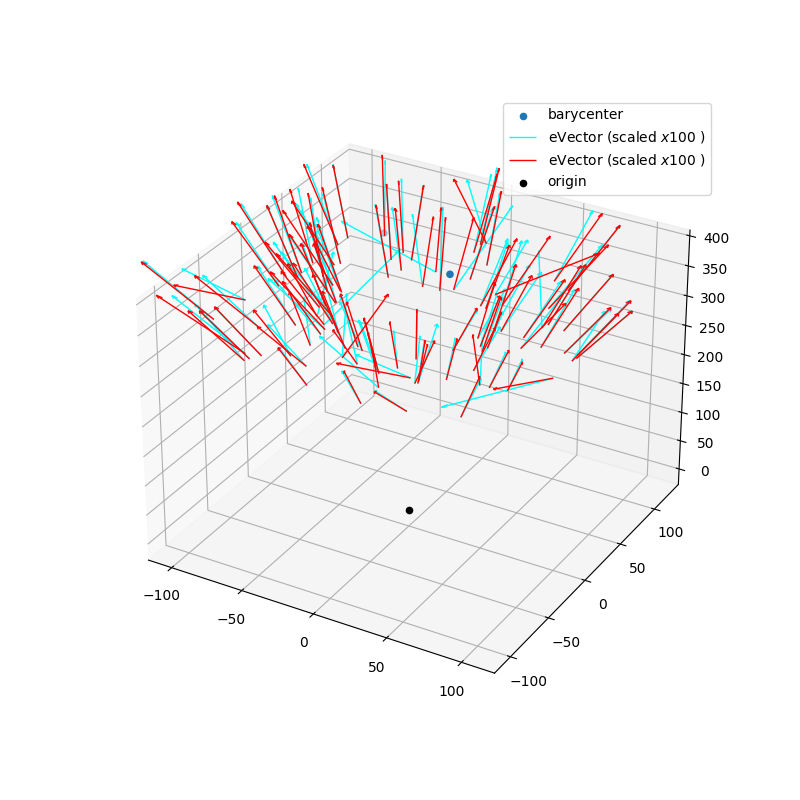

In [429]:
fig = plt.figure(figsize= (8,8))
ax = plt.axes(projection ='3d')
N = 100
ax.quiver(                                        # eVector
    boundary[:N, 0], boundary[:N, 1], boundary[:N, 2],
    u[:N, 0], u[:N, 1], u[:N, 2],
    arrow_length_ratio=0.05, color = 'cyan' , linewidth = 1 ,  length=100 , label = r'eVector (scaled $x100$ )'
)
ax.quiver(                                        # eVector new
    boundary[:N, 0], boundary[:N, 1], boundary[:N, 2],
    u_LC1rm[:N, 0], u_LC1rm[:N, 1], u_LC1rm[:N, 2],
    arrow_length_ratio=0.05, color = 'red' , linewidth = 1 ,  length=100 , label = r'Modified: eVector (scaled $x100$ )'
)
ax.scatter3D(0, 0, 0, color = 'black', label= 'origin')
# ax.set_xlim([-60, 60])
# ax.set_ylim([-60, 60])
# ax.set_zlim([0, 500])
plt.legend()
plt.show()

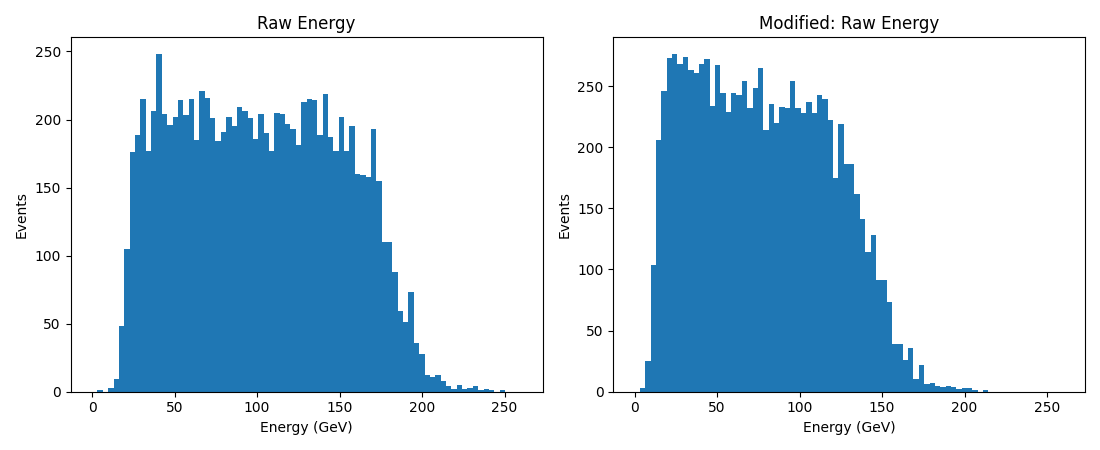

In [253]:
fig , axs = plt.subplots(1,2, figsize=(11,4.5))

axs[0].hist(ak.to_numpy(baryenergy_raw_SC_ON[:Evts,0]), bins=80, range=(0,260))
axs[0].set_xlabel(r'Energy (GeV)')
axs[0].set_ylabel(r'Events')
axs[0].set_title(r'Raw Energy')

axs[1].hist(baryenergy_raw_LC1rm[:Evts], bins=80, range=(0,260))
axs[1].set_xlabel(r'Energy (GeV)')
axs[1].set_ylabel(r'Events')
axs[1].set_title(r'Modified: Raw Energy')

plt.tight_layout()
plt.show()

In [412]:
(sum(baryenergy_raw_SC_ON[:Evts,0])-sum(baryenergy_raw_LC1rm[:Evts]))/sum(baryenergy_raw_SC_ON[:Evts,0])

0.23557408010252812

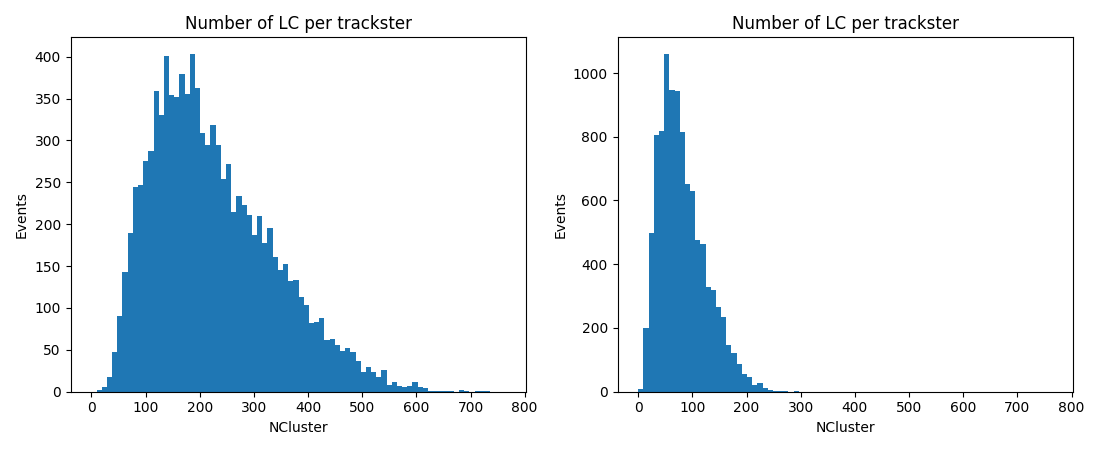

In [440]:
fig , axs = plt.subplots(1,2, figsize=(11,4.5))

axs[0].hist(ak.to_numpy(NClusters_SC_ON[:Evts]), bins=80, range=(0,765))
axs[0].set_xlabel(r'NCluster')
axs[0].set_ylabel(r'Events')
axs[0].set_title(r'Number of LC per trackster')

axs[1].hist(NClusters_LC1rm[:Evts], bins=80, range=(0,765))
axs[1].set_xlabel(r'NCluster')
axs[1].set_ylabel(r'Events')
axs[1].set_title(r'Number of LC per trackster') 

plt.tight_layout()
plt.show()

In [436]:
(sum(NClusters_SC_ON[:Evts])-sum(NClusters_LC1rm[:Evts]))/sum(NClusters_SC_ON[:Evts])

0.6387343500420867

In [441]:
np.sum(NClusters_LC1rm[:Evts])

817611.0

##### Angle bw EVector and BoundaryP

In [579]:
cos_theta = np.sum(abs(w_norm[:Evts, :]*u[:Evts, :]), axis = 1)
theta = np.arccos(cos_theta)*180/np.pi

cos_theta_LC1rm = np.sum(abs(w_norm[:Evts, :]*u_LC1rm[:Evts, :]), axis = 1)
theta_LC1rm = np.arccos(cos_theta_LC1rm)*180/np.pi

###### Angle

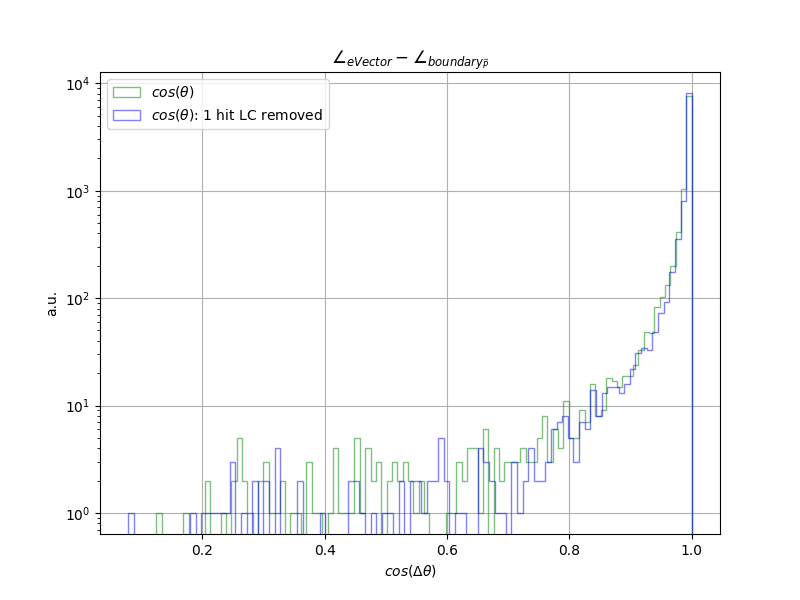

In [416]:
plt.figure(figsize=(8, 6))

n, bins, _ = plt.hist(cos_theta, bins=100, color= 'green', histtype='step', alpha = 0.5, label = r'$cos(\theta)$')#, range = (-0.2, 0.2) )
n_new, bins_new, __new = plt.hist(cos_theta_LC1rm, bins=100, histtype='step', color= 'blue', alpha =0.5, label = r'$cos(\theta)$: 1 hit LC removed')

plt.xlabel(r'$ cos(\Delta\theta)$')
plt.ylabel('a.u.')
plt.yscale('log')
plt.title(r'$ \angle_{eVector} - \angle_{boundary_{\vec{P}}}$') #, x = 0.3, y = 0.92
plt.legend()
plt.grid()
plt.show()

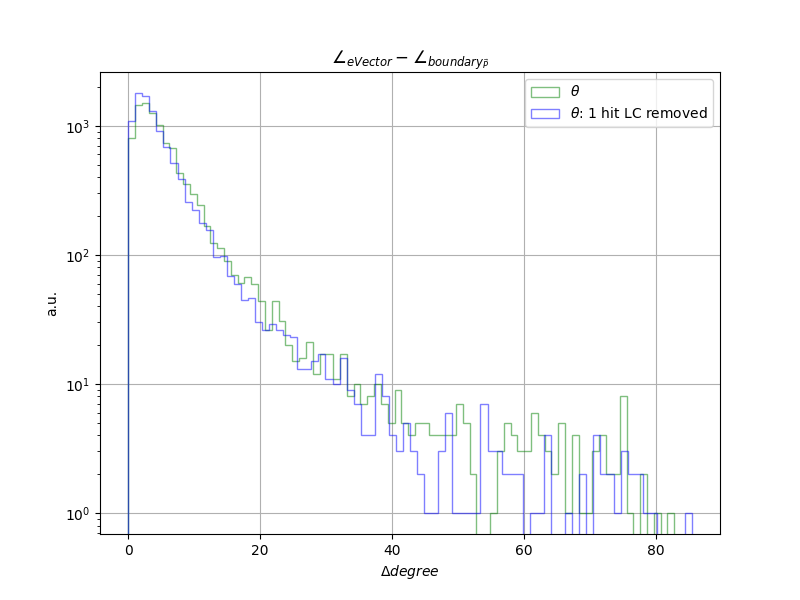

In [417]:
plt.figure(figsize=(8, 6))

n, bins, _ = plt.hist(theta, bins=80, color= 'green',histtype='step', alpha = 0.5, label = r'$\theta$')#, range = (-0.2, 0.2) )
n_new, bins_new, __new = plt.hist(theta_LC1rm, bins=80,histtype='step', color= 'blue', alpha = 0.5, label = r'$\theta$: 1 hit LC removed')

plt.xlabel(r'$\Delta degree$') 
plt.ylabel('a.u.')
plt.yscale('log')
plt.title(r'$ \angle_{eVector} - \angle_{boundary_{\vec{P}}}$') #, x = 0.3, y = 0.92
plt.legend()
plt.grid()
plt.show()

###### theta vs Energy

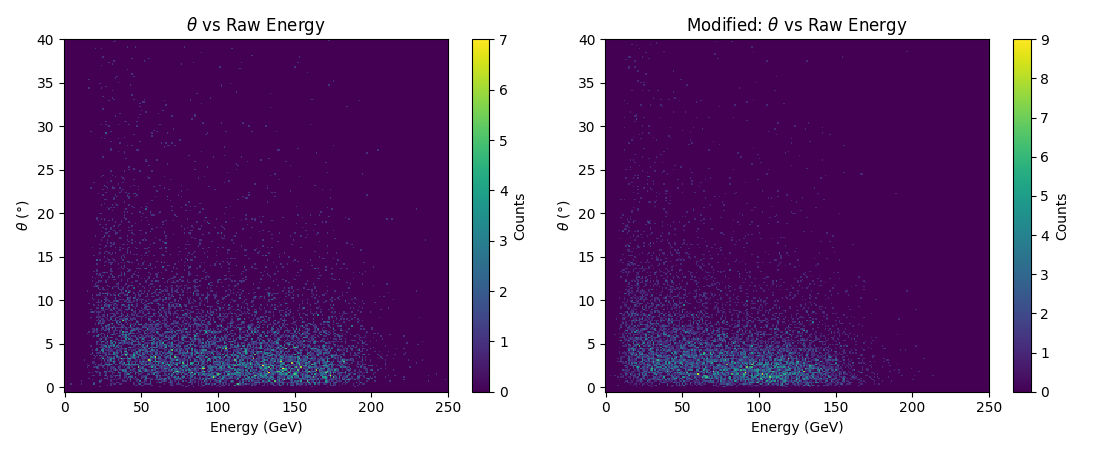

In [586]:
fig , axs = plt.subplots(1,2, figsize=(11,4.5))

h = axs[0].hist2d(ak.to_numpy(baryenergy_raw_SC_ON[:Evts,0]), ak.to_numpy(theta[:Evts]), bins=250,range=((-0.5,250),(-0.5,40))) #, cmap='Greens'
fig.colorbar(h[3], ax=axs[0], label='Counts')

axs[0].set_xlabel(r'Energy (GeV)')
axs[0].set_ylabel(r'$\theta\ (\degree)$')
axs[0].set_title(r'$\theta$ vs Raw Energy')

h = axs[1].hist2d(baryenergy_raw_LC1rm[:Evts], ak.to_numpy(theta_LC1rm[:Evts]), bins=250,range=((-0.5,250),(-0.5,40))) #, cmap='Reds'
fig.colorbar(h[3], ax=axs[1], label='Counts')

axs[1].set_xlabel(r'Energy (GeV)')
axs[1].set_ylabel(r'$\theta\ (\degree)$')
axs[1].set_title(r'Modified: $\theta$ vs Raw Energy')

plt.tight_layout()
plt.show()

###### theta vs Eta

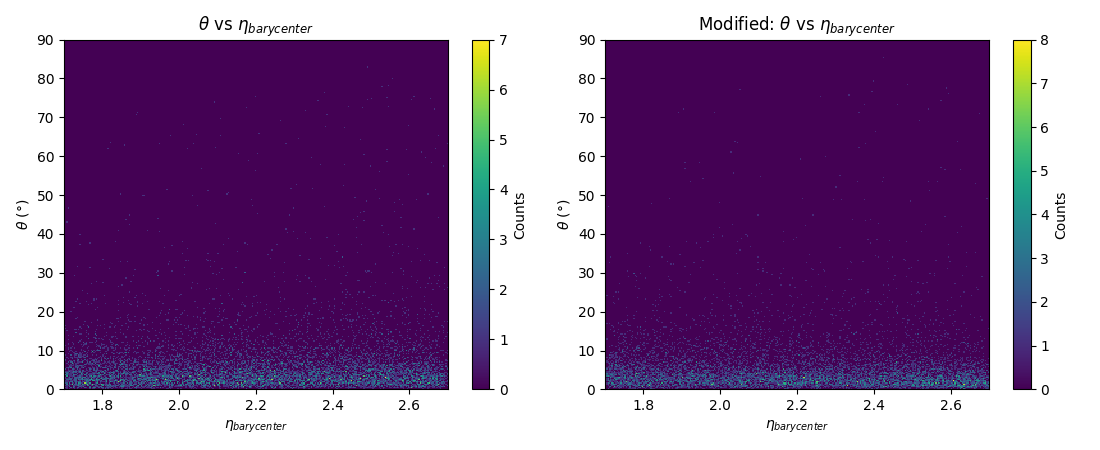

In [418]:
fig , axs = plt.subplots(1,2, figsize=(11,4.5))

h = axs[0].hist2d(ak.to_numpy(barycenters_eta_SC_ON[:Evts,0]), ak.to_numpy(theta[:Evts]), bins=300, range=((1.7,2.7),(0, 90))) #, cmap='Greens'
fig.colorbar(h[3], ax=axs[0], label='Counts')

axs[0].set_xlabel(r'$\eta_{barycenter}$')
axs[0].set_ylabel(r'$\theta\ (\degree)$')
axs[0].set_title(r'$ \theta$ vs $\eta_{barycenter}$')

h = axs[1].hist2d(ak.to_numpy(eta(bary_LC1rm[:Evts,0], bary_LC1rm[:Evts,1], bary_LC1rm[:Evts,2])), ak.to_numpy(theta_LC1rm[:Evts]), bins=300, range=((1.7,2.7),(0, 90))) #, cmap='Reds'
fig.colorbar(h[3], ax=axs[1], label='Counts')

axs[1].set_xlabel(r'$\eta_{barycenter}$')
axs[1].set_ylabel(r'$\theta\ (\degree)$')
axs[1].set_title(r'Modified: $\theta$ vs $\eta_{barycenter}$')

plt.tight_layout()
plt.show()

###### theta vs NCluster

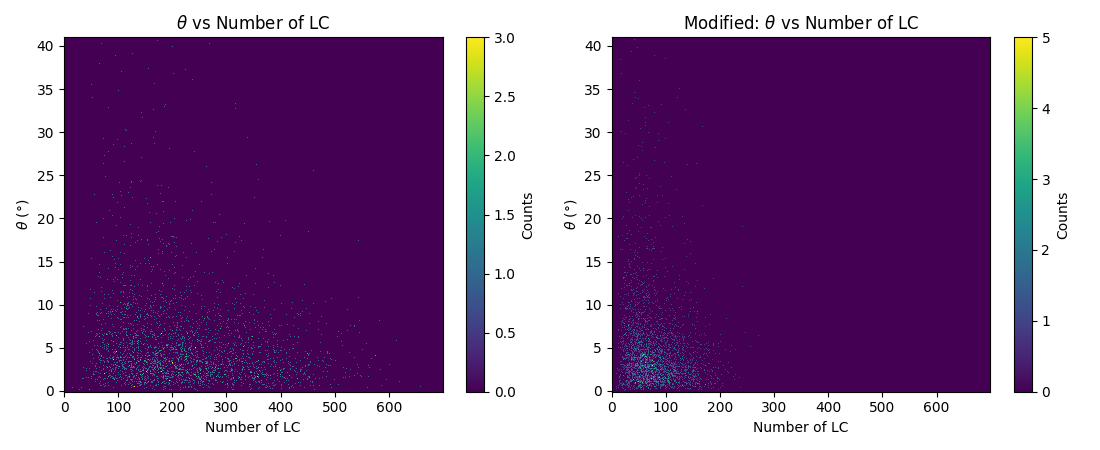

In [585]:
fig , axs = plt.subplots(1,2, figsize=(11,4.5))

h = axs[0].hist2d(ak.to_numpy(NClusters_SC_ON[:Evts]), ak.to_numpy(theta[:Evts]), bins=700, range = ((-0.5,699.5),(-0.1,41))) #, cmap='Greens'
fig.colorbar(h[3], ax=axs[0], label='Counts')

axs[0].set_xlabel(r'Number of LC')
axs[0].set_ylabel(r'$\theta\ (\degree)$')
axs[0].set_title(r'$ \theta$ vs Number of LC')

h = axs[1].hist2d(ak.to_numpy(NClusters_LC1rm[:Evts]), ak.to_numpy(theta_LC1rm[:Evts]), bins=700, range = ((-0.5,699.5),(-0.1,41))) #, cmap='Reds'
fig.colorbar(h[3], ax=axs[1], label='Counts')

axs[1].set_xlabel(r'Number of LC')
axs[1].set_ylabel(r'$\theta\ (\degree)$')
axs[1].set_title(r'Modified: $\theta$ vs Number of LC')

plt.tight_layout()
plt.show()

###### theta vs EV

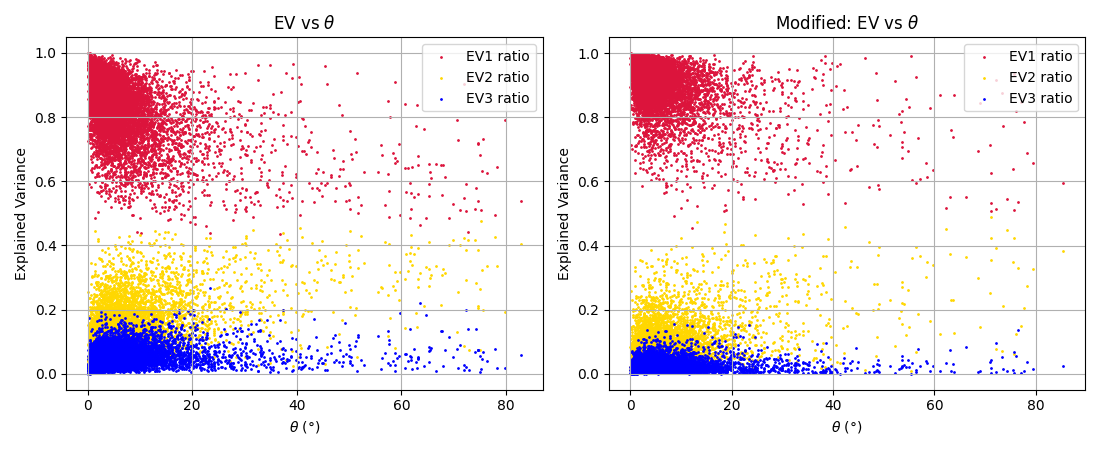

In [422]:
fig , axs = plt.subplots(1,2, figsize=(11,4.5))

EV_sum = (EV_SC_ON["EV1"]+EV_SC_ON["EV2"]+EV_SC_ON["EV3"])[:Evts]
axs[0].scatter(theta[:Evts], EV_SC_ON["EV1"][:Evts]/EV_sum , s = 1 , color = 'crimson', label = 'EV1 ratio')
axs[0].scatter(theta[:Evts], EV_SC_ON["EV2"][:Evts]/EV_sum , s = 1 , color = 'gold', label = 'EV2 ratio')
axs[0].scatter(theta[:Evts], EV_SC_ON["EV3"][:Evts]/EV_sum , s = 1, color = 'blue', label = 'EV3 ratio')

axs[0].set_ylabel(r'Explained Variance')
axs[0].set_xlabel(r'$\theta\ (\degree)$')
axs[0].set_title(r'EV vs $ \theta$') 
axs[0].legend()
axs[0].grid()

axs[1].scatter(theta_LC1rm[:Evts], EV_LC1rm[:Evts,0] , s = 1 , color = 'crimson', label = 'EV1 ratio')
axs[1].scatter(theta_LC1rm[:Evts], EV_LC1rm[:Evts,1] , s = 1 , color = 'gold', label = 'EV2 ratio')
axs[1].scatter(theta_LC1rm[:Evts], EV_LC1rm[:Evts,2] , s = 1, color = 'blue', label = 'EV3 ratio')

axs[1].set_ylabel(r'Explained Variance')
axs[1].set_xlabel(r'$\theta\ (\degree)$')
axs[1].set_title(r'Modified: EV vs $ \theta$') 

axs[1].legend()
axs[1].grid()
plt.tight_layout()
plt.show()

###### Energy vs NCluster

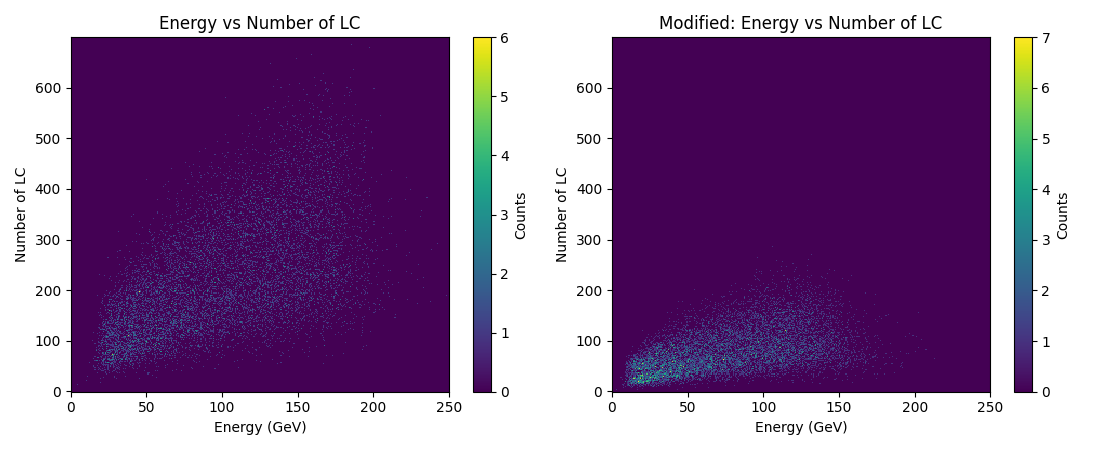

In [530]:
fig , axs = plt.subplots(1,2, figsize=(11,4.5))

h = axs[0].hist2d(ak.to_numpy(baryenergy_raw_SC_ON[:Evts,0]) , ak.to_numpy(NClusters_SC_ON[:Evts]), bins=350, range=((0,250),(-0.5,699.5))) #, cmap='Greens'
fig.colorbar(h[3], ax=axs[0], label='Counts')

axs[0].set_ylabel(r'Number of LC')
axs[0].set_xlabel(r'Energy (GeV)')
axs[0].set_title(r'Energy vs Number of LC')

h = axs[1].hist2d(baryenergy_raw_LC1rm[:Evts] , ak.to_numpy(NClusters_LC1rm[:Evts]), bins=350, range=((0,250),(-0.5,699.5))) #, cmap='Reds'
fig.colorbar(h[3], ax=axs[1], label='Counts')

axs[1].set_ylabel(r'Number of LC')
axs[1].set_xlabel(r'Energy (GeV)')
axs[1].set_title(r'Modified: Energy vs Number of LC')

plt.tight_layout()
plt.show()

###### Binned plots

In [115]:
bin_edges = np.linspace(min(theta), max(theta), num=30)
bin_centers = 0.5*(bin_edges[1:]+bin_edges[:-1])
bin_indices = np.digitize(theta, bin_edges)
avgNCluster = []
avgEnergy_per_LC = []
n_datapts = []
for i in range(1, len(bin_edges)):
    in_bin = (bin_indices == i)
    if np.any(in_bin):
        avg1 = np.mean(NClusters_SC_ON[in_bin])
        avg2 = np.mean(baryenergy_raw_SC_ON[in_bin]/NClusters_SC_ON[in_bin])
    else:
        avg1 = np.nan  
        avg2 = np.nan
    avgNCluster.append(avg1)
    avgEnergy_per_LC.append(avg2)
    n_datapts.append(np.sum(in_bin))

bin_edges_LC1rm = np.linspace(min(theta_LC1rm), max(theta_LC1rm), num=30)
bin_centers_LC1rm = 0.5*(bin_edges_LC1rm[1:]+bin_edges_LC1rm[:-1])
bin_indices_LC1rm = np.digitize(theta_LC1rm, bin_edges_LC1rm)
avgNCluster_LC1rm = []
avgEnergy_LC1rm_per_LC = []
n_datapts_LC1rm = []
for i in range(1, len(bin_edges_LC1rm)):
    in_bin = (bin_indices_LC1rm == i)
    if np.any(in_bin):
        avg1_LC1rm = np.mean(NClusters_SC_ON[in_bin])
        avg2_LC1rm = np.mean(baryenergy_raw_SC_ON[in_bin]/NClusters_SC_ON[in_bin])
    else:
        avg1_LC1rm = np.nan  
        avg2_LC1rm = np.nan
    avgNCluster_LC1rm.append(avg1_LC1rm)
    avgEnergy_LC1rm_per_LC.append(avg2_LC1rm)
    n_datapts_LC1rm.append(np.sum(in_bin))

C:\Users\chand\AppData\Local\Temp\ipykernel_14664\1747988914.py:7: RuntimeWarning: divide by zero encountered in divide
  plt.errorbar(bin_centers , avgNCluster, yerr=50/(np.sqrt(n_datapts)), fmt="o")


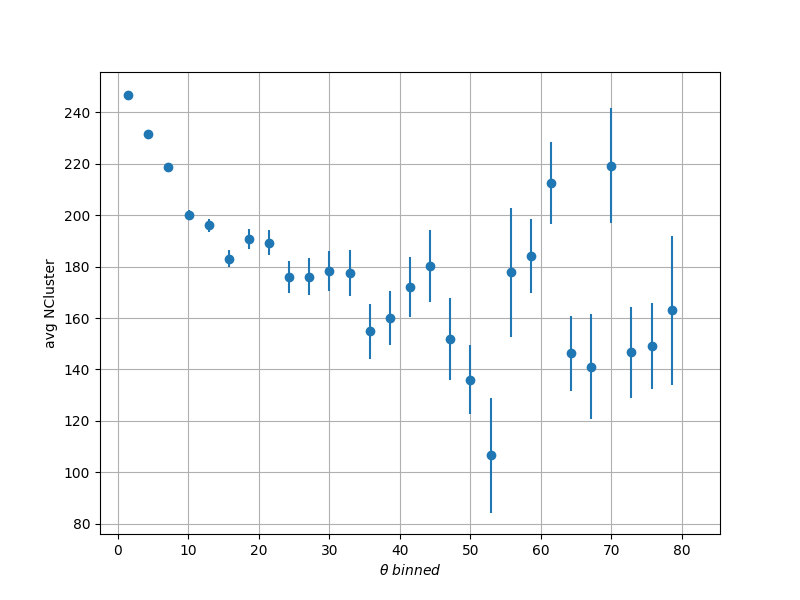

In [116]:
# plt.close()
# bin_edges
# bin_indices
# avgEnergy_LC
plt.figure(figsize=(8, 6))
# plt.scatter(bin_centers , avgEnergy_LC)
plt.errorbar(bin_centers , avgNCluster, yerr=50/(np.sqrt(n_datapts)), fmt="o")
# plt.errorbar(bin_centers , avgNCluster, yerr=50/(np.sqrt(n_datapts)), fmt="o")

plt.xlabel(r"$\theta \ binned$")
plt.ylabel("avg NCluster")
plt.grid()
plt.show()

C:\Users\chand\AppData\Local\Temp\ipykernel_14664\1280886472.py:7: RuntimeWarning: divide by zero encountered in divide
  plt.errorbar(bin_centers , avgEnergy_per_LC, yerr=1/(np.sqrt(n_datapts)), fmt="o")


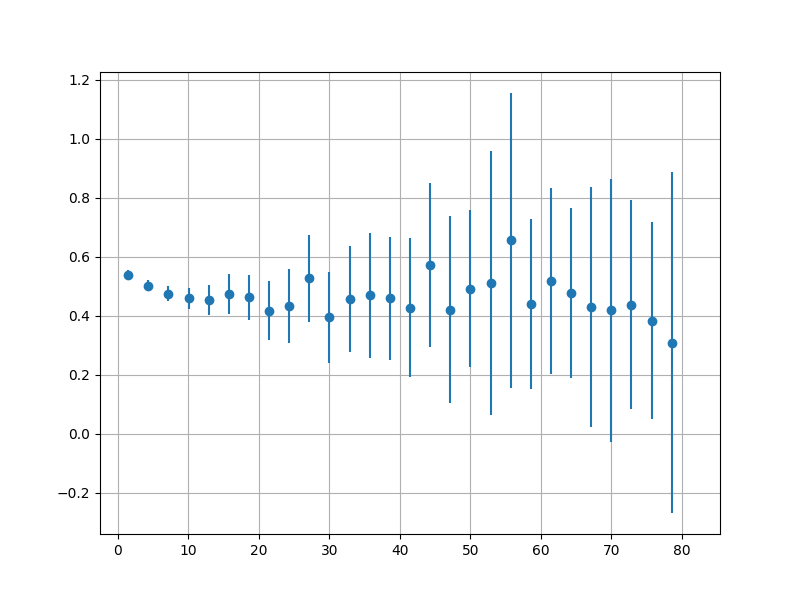

In [117]:
# plt.close()
# bin_edges
# bin_indices
# avgEnergy_per_LC
plt.figure(figsize=(8, 6))
# plt.scatter(bin_centers , avgEnergy_per_LC)
plt.errorbar(bin_centers , avgEnergy_per_LC, yerr=1/(np.sqrt(n_datapts)), fmt="o")
plt.grid()
plt.show()

## SC

###### Visualisation

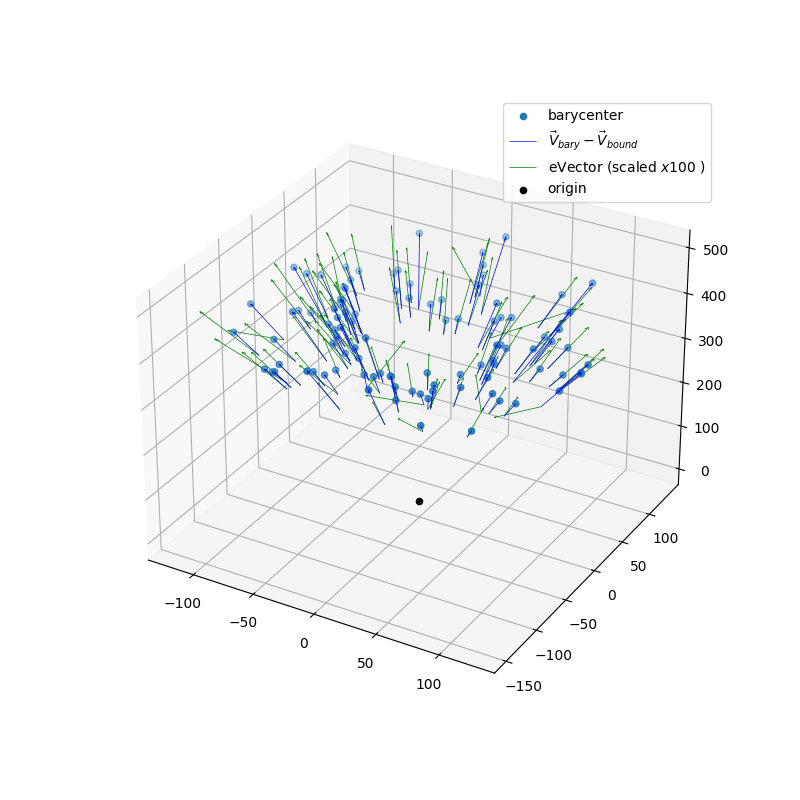

In [554]:
fig = plt.figure(figsize= (8,8))
ax = plt.axes(projection ='3d')
N = 100
# ax.scatter3D(evector_x_SC_ON, evector_y_SC_ON, evector_z_SC_ON)


origins = np.zeros(3) #   boundary # 
# ax.quiver(                                        # barycenter - boundary
#     boundary[:N, 0], boundary[:N, 1], boundary[:N, 2],
#     boundaryP[:N, 0], boundaryP[:N, 1], boundaryP[:N, 2],
#     normalize=False, arrow_length_ratio=0.05, color= 'green' , linewidth = 0.5 , label = r'$ \vec{P}_{bound}$' # , length=0.1 
# )

# ax.quiver(                                        # barycenter 
#     origins[ 0], origins[1], origins[2],
#     bary_LC1rm[:N, 0] , bary_LC1rm[:N, 1] , bary_LC1rm[:N, 2] ,
#     normalize=False, arrow_length_ratio=0.02, color= 'red' , linewidth = 0.5 # , length=0.1 
# )
ax.scatter3D(bary_LC1rm[:N,0], bary_LC1rm[:N,1], bary_LC1rm[:N,2], label = 'barycenter')


ax.quiver(                                        # barycenter - boundary
    boundary[:N, 0], boundary[:N, 1], boundary[:N, 2],
    bary_LC1rm[:N, 0] - boundary[:N, 0], bary_LC1rm[:N, 1] - boundary[:N, 1], bary_LC1rm[:N, 2] - boundary[:N, 2],
    normalize=False, arrow_length_ratio=0.05, color= 'blue' , linewidth = 0.5 , label = r'$ \vec{V}_{bary}-\vec{V}_{bound} $' # , length=0.1 
)

# ax.quiver(                                        # boundary
#     origins[ 0], origins[1], origins[2],
#     boundary[:N, 0], boundary[:N, 1], boundary[:N, 2],
#     normalize=False, arrow_length_ratio=0.05, color= 'black' , linewidth = 0.3 # , length=0.1 
# )

ax.quiver(                                        # eVector
    boundary[:N, 0], boundary[:N, 1], boundary[:N, 2],
    u_LC1rm[:N, 0], u_LC1rm[:N, 1], u_LC1rm[:N, 2],
    arrow_length_ratio=0.05, color = 'green' , linewidth = 0.5 ,  length=100 , label = r'eVector (scaled $x100$ )'
)

ax.scatter3D(0, 0, 0, color = 'black', label= 'origin')

# ax.set_xlim([-100, 100])
# ax.set_ylim([-100, 100])
# ax.set_zlim([0, 500])
plt.legend()
plt.show()

### Plots

###### Boundary Momentum, Boundary-Barycenter

In [548]:
cos_theta = np.sum(((bary_LC1rm-boundary)/np.linalg.norm(bary_LC1rm-boundary, axis = -1, keepdims=True))*w_norm, axis = 1)
theta = np.arccos(np.clip(cos_theta, -1.0, 1.0))*180/np.pi
title_ = r'$ \theta : Boundary-Barycenter \ and\ \vec{P}_{{bound\_norm}} $'

###### Evector, Boundary-Barycenter

In [400]:
cos_theta = np.sum(abs(evector_LC1rm*(bary_LC1rm-boundary)/np.linalg.norm(bary_LC1rm-boundary, axis = -1, keepdims=True)), axis = 1)
theta = np.arccos(np.clip(cos_theta, -1.0, 1.0))*180/np.pi
title_ = r'$ \theta : evector \ and\ Boundary-Barycenter $'

###### Boundary Momentum, Evector

In [539]:
cos_theta = np.sum(abs(evector_LC1rm*w_norm), axis = 1)
theta = np.arccos(np.clip(cos_theta, -1.0, 1.0))*180/np.pi
title_ = r'$ \theta : evector \ and\ \vec{P}_{{bound\_norm}} $'

###### Origin-Boundary, Origin-Barycenter

In [546]:
cos_theta = np.sum(boundary_norm*v_LC1rm_norm, axis = 1)
theta = np.arccos(np.clip(cos_theta, -1.0, 1.0))*180/np.pi
title_ = r'$ \theta$ : O-Barycenter & O-Boundary'

###### 

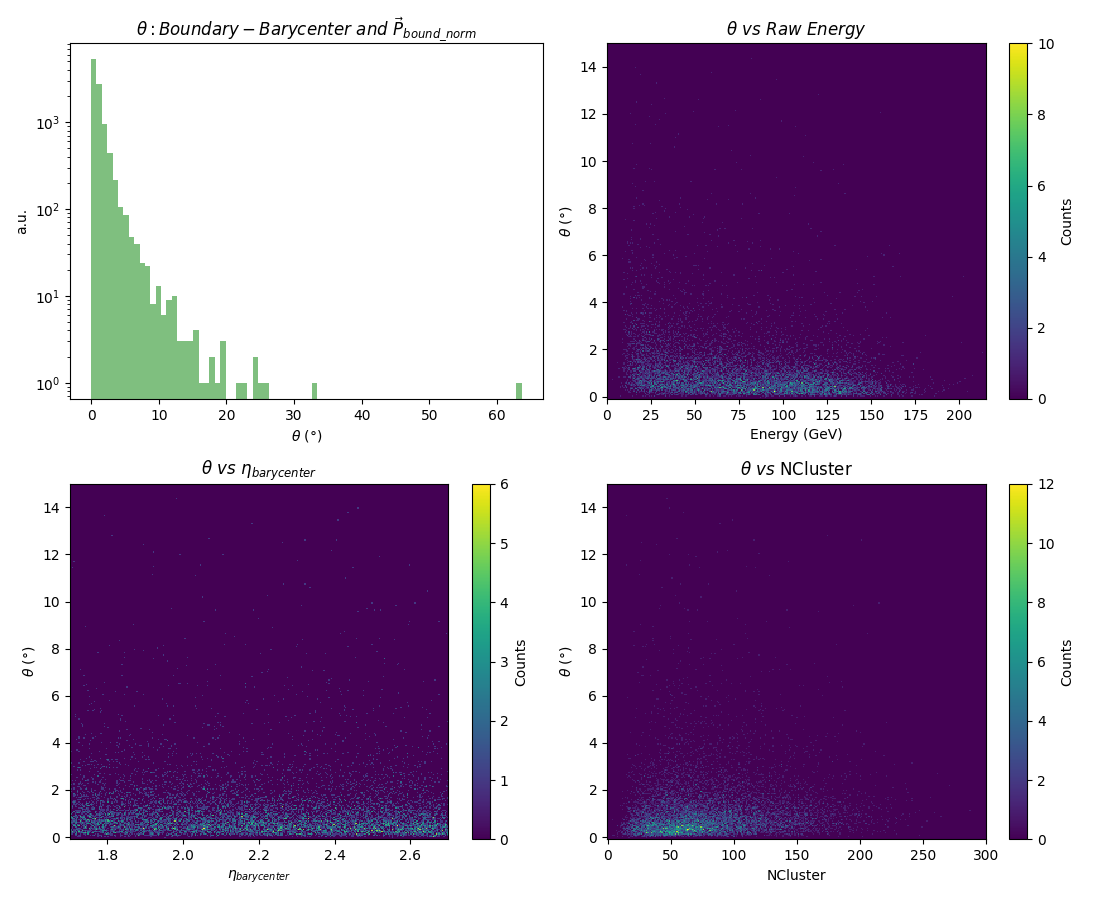

In [549]:
fig , axs = plt.subplots(2,2, figsize=(11,9))

h = axs[0,0].hist(theta, bins=80, color= 'green', alpha = 0.5)

axs[0,0].set_ylabel('a.u.')
axs[0,0].set_xlabel(r'$\theta\ (\degree)$')
axs[0,0].set_yscale('log')
axs[0,0].set_title(title_) 

h = axs[0,1].hist2d(ak.to_numpy(baryenergy_raw_LC1rm), ak.to_numpy(theta) , bins = 300, range=((0,215),(-0.1,15)))
fig.colorbar(h[3], ax=axs[0,1], label='Counts')

axs[0,1].set_xlabel(r'Energy (GeV)')
axs[0,1].set_ylabel(r'$\theta\ (\degree)$')
axs[0,1].set_title(r'$ \theta\ vs\ Raw\ Energy$')

h = axs[1,0].hist2d(eta_vec(bary_LC1rm), ak.to_numpy(theta) , bins = 300, range=((1.7,2.7),(-0.1,15)))
fig.colorbar(h[3], ax=axs[1,0], label='Counts')

axs[1,0].set_xlabel(r'$\eta_{barycenter}$')
axs[1,0].set_ylabel(r'$\theta\ (\degree)$')
axs[1,0].set_title(r'$ \theta\ vs\ \eta_{barycenter}$')

h = axs[1,1].hist2d(NClusters_LC1rm, ak.to_numpy(theta) , bins = 300, range=((-0.5,300),(-0.1,15)))
fig.colorbar(h[3], ax=axs[1,1], label='Counts')

axs[1,1].set_xlabel(r'NCluster')
axs[1,1].set_ylabel(r'$\theta\ (\degree)$')
axs[1,1].set_title(r'$ \theta\ vs\ $NCluster')

plt.tight_layout()
plt.show()

In [545]:
plt.close()

## C3DH

#### Selecting PCA Eigenvector

In [776]:
# Weighted tracksters:
# evector_weighted_tc3d_ON = []
# barycenter_weighted_tc3d_ON = []

# # for evnt in range(len(baryenergy_raw_tc3d_ON[:])):
# #     evector_weighted_tc3d_ON.append(np.average([evector_x_tc3d_ON[evnt],evector_y_tc3d_ON[evnt],evector_z_tc3d_ON[evnt]], weights = baryenergy_raw_tc3d_ON[evnt], axis = 1))
# #     barycenter_weighted_tc3d_ON.append(np.average([bary_x_tc3d_ON[evnt],bary_y_tc3d_ON[evnt],bary_z_tc3d_ON[evnt]], weights = baryenergy_raw_tc3d_ON[evnt], axis = 1))

# # Best scoring tracksters:
sorted_trackster_top1 = c3dh_simToReco_SC[ak.argsort(c3dh_simToReco_SC_score)][:,:1]
barycenter_tc3d_top1 = [bary_x_tc3d_ON[sorted_trackster_top1] , bary_y_tc3d_ON[sorted_trackster_top1] , bary_z_tc3d_ON[sorted_trackster_top1]]
evector_tc3d_top1 = [evector_x_tc3d_ON[sorted_trackster_top1] , evector_y_tc3d_ON[sorted_trackster_top1] , evector_z_tc3d_ON[sorted_trackster_top1]]
baryenergy_raw_tc3d_top1 = baryenergy_raw_tc3d_ON[sorted_trackster_top1][:,0]
NClusters_tc3d_top1 = ak.sum(ak.num(vertices_indexes_tc3d_ON[sorted_trackster_top1], axis=-1), axis = 1)

EV_sum_tc3d = (EV_tc3d_ON["EV1"][sorted_trackster_top1]+EV_tc3d_ON["EV2"][sorted_trackster_top1]+EV_tc3d_ON["EV3"][sorted_trackster_top1])
EV_tc3d_top1 = np.stack([EV_tc3d_ON["EV1"][sorted_trackster_top1][:,0]/EV_sum_tc3d[:,0] , EV_tc3d_ON["EV2"][sorted_trackster_top1][:,0]/EV_sum_tc3d[:,0] , EV_tc3d_ON["EV3"][sorted_trackster_top1][:,0]/EV_sum_tc3d[:,0]], axis = -1)


# Highest (top 2) scoring tracksters:
sorted_trackster_top2 = c3dh_simToReco_SC[ak.argsort(c3dh_simToReco_SC_score)][:,:2]
# evector_tc3d_ON = ak.Array([evector_x_tc3d_ON[sorted_trackster][:,0] , evector_y_tc3d_ON[sorted_trackster][:,0] , evector_z_tc3d_ON[sorted_trackster][:,0]])
# barycenter__tc3d_ON = ak.Array([bary_x_tc3d_ON[sorted_trackster][:,0] , bary_y_tc3d_ON[sorted_trackster][:,0] , bary_z_tc3d_ON[sorted_trackster][:,0]])

In [777]:
Evts = len(x_SC_ON[:10000])
# trackster_arr = []
baryenergy_raw_tc3d_top2 = np.zeros(Evts)
EV_tc3d_top2 = np.zeros((Evts,3))
NClusters_tc3d_top2 = np.zeros(Evts)
evector_tc3d_top2 = np.zeros((Evts,3))
bary_tc3d_top2 = np.zeros((Evts,3))

for event in range(Evts):
    layer_clusters = [
        LayerClusters(x_tc3d_ON[sorted_trackster_top2][event], 
                     y_tc3d_ON[sorted_trackster_top2][event], 
                     z_tc3d_ON[sorted_trackster_top2][event], 
                     energy_tc3d_ON[sorted_trackster_top2][event])
    ]
    
    trackster_tc3d = Trackster()
    trackster_tc3d._vertices = ak.flatten(vertices_indexes_tc3d_ON[sorted_trackster_top2], axis = -1)[event]
    assign_pca_to_tracksters([trackster_tc3d], layer_clusters, energy_weight=True)#, clean=False)

    # Calculating explained variance
    total_variance = np.sum(trackster_tc3d._eigenvalues)
    explained_variance_ratio = trackster_tc3d._eigenvalues[::-1] / total_variance if total_variance > 0 else np.zeros(3)
    
    baryenergy_raw_tc3d_top2[event] = trackster_tc3d._raw_energy
    NClusters_tc3d_top2[event] = trackster_tc3d._NCLusters_for_PCA
    evector_tc3d_top2[event] = trackster_tc3d._eigenvectors[:,2]
    bary_tc3d_top2[event] = [trackster_tc3d._barycenter.x , trackster_tc3d._barycenter.y , trackster_tc3d._barycenter.z]
    EV_tc3d_top2[event] = explained_variance_ratio 
    # trackster_arr.append(trackster_tc3d)

##### Defining unit Vectors

In [778]:
# Highest scored / Weighted trackster
u_tc3d_top1 = ak.Array(np.stack([evector_tc3d_top1[0] , evector_tc3d_top1[1] , evector_tc3d_top1[2]], axis = -1))[:,0]
v_tc3d_top1 = ak.Array(np.stack([barycenter_tc3d_top1[0] , barycenter_tc3d_top1[1] , barycenter_tc3d_top1[2]], axis = -1))[:,0]
v_tc3d_top1_norm = v_tc3d_top1/np.linalg.norm(v_tc3d_top1, axis = 1, keepdims=True) 

# Top 2 trackster
u_tc3d_top2 = evector_tc3d_top2
v_tc3d_top2_norm = bary_tc3d_top2/np.linalg.norm(bary_tc3d_top2, axis = 1, keepdims=True) 

#### Visulation

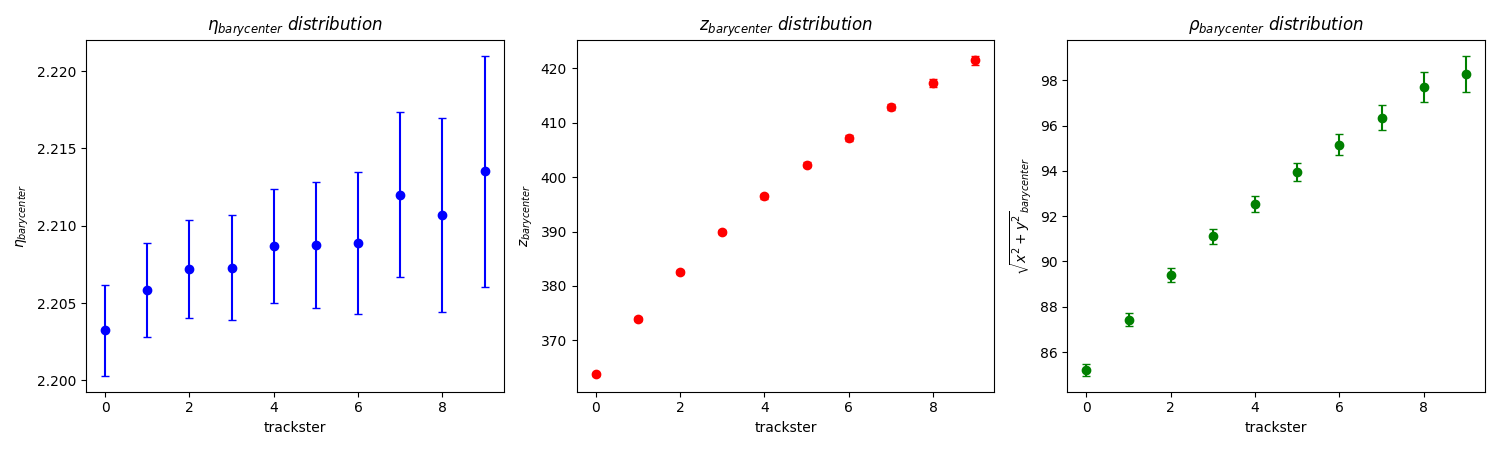

In [800]:
fig , axs = plt.subplots(1,3, figsize=(15,4.5))
x = 11
X = np.sqrt(bary_y_tc3d_ON[ak.argsort(c3dh_simToReco_SC_score)]**2+bary_x_tc3d_ON[ak.argsort(c3dh_simToReco_SC_score)]**2)
means = ak.mean(X, axis=0)[:-x]
errors = (ak.std(X, axis=0) / np.sqrt(ak.count(X, axis=0)))[:-x]
axs[2].errorbar(np.arange(len(means)), means, yerr=errors, fmt='o', capsize=3, color= 'green')

axs[2].set_ylabel(r'$\sqrt{x^2+y^2}_{barycenter}$')
axs[2].set_xlabel(r'trackster')
axs[2].set_title(r'$\rho_{barycenter}\ distribution$') 

Y = bary_z_tc3d_ON[ak.argsort(c3dh_simToReco_SC_score)]
means = ak.mean(Y, axis=0)[:-x]
errors = (ak.std(Y, axis=0) / np.sqrt(ak.count(Y, axis=0)))[:-x]
axs[1].errorbar(np.arange(len(means)), means, yerr=errors, fmt='o', capsize=3, color= 'red')

axs[1].set_ylabel(r'$z_{barycenter}$')
axs[1].set_xlabel(r'trackster')
axs[1].set_title(r'$z_{barycenter}\ distribution$')

Z = barycenters_eta_tc3d_ON[ak.argsort(c3dh_simToReco_SC_score)]
means = ak.mean(Z, axis=0)[:-x]
errors = (ak.std(Z, axis=0) / np.sqrt(ak.count(Z, axis=0)))[:-x]
axs[0].errorbar(np.arange(len(means)), means, yerr=errors, fmt='o', capsize=3, color= 'blue')

axs[0].set_ylabel(r'$\eta_{barycenter}$')
axs[0].set_xlabel(r'trackster')
axs[0].set_title(r'$\eta_{barycenter}\ distribution$')
plt.tight_layout()
plt.show()


#### Plots

Select one of the angles to study

In [877]:
## Angle bw SC and tc3d eigenvector

title_ = r'$ eVector_{sim}\ &\ eVector_{tc3d} $'
cos_theta_1 = np.sum(abs(u_tc3d_top1*u_LC1rm), axis = 1)
theta_1 = ak.to_numpy(np.arccos(np.clip(cos_theta_1, -1.0, 1.0))*180/np.pi)

cos_theta_2 = np.sum(abs(u_tc3d_top2*u_LC1rm), axis = 1)
theta_2 = ak.to_numpy(np.arccos(cos_theta_2)*180/np.pi)

# ---------------------- OR ------------------------------
## Angle bw 000_to_SC_boundary and eigenvector

# title_ = r'$ O-Boundary_{sim}\ &\ eVector $'
# cos_theta_1 = np.sum(abs(u_tc3d_top1*boundary_norm), axis = 1)
# theta_1 = ak.to_numpy(np.arccos(np.clip(cos_theta_1, -1.0, 1.0))*180/np.pi)

# cos_theta_2 = np.sum(abs(u_tc3d_top2*boundary_norm), axis = 1)
# theta_2 = ak.to_numpy(np.arccos(cos_theta_2)*180/np.pi)

# cos_theta_3 = np.sum(abs(u_LC1rm*boundary_norm), axis = 1)
# theta_3 = ak.to_numpy(np.arccos(cos_theta_3)*180/np.pi)

# ---------------------- OR ------------------------------
## Angle bw 000_to_SC_bary and eigenvector

title_ = r'$ O-Barycenter_{sim}\ &\ eVector $'
cos_theta_1 = np.sum(abs(u_tc3d_top1*v_LC1rm_norm), axis = 1)
theta_1 = ak.to_numpy(np.arccos(np.clip(cos_theta_1, -1.0, 1.0))*180/np.pi)

cos_theta_2 = np.sum(abs(u_tc3d_top2*v_LC1rm_norm), axis = 1)
theta_2 = ak.to_numpy(np.arccos(cos_theta_2)*180/np.pi)

cos_theta_3 = np.sum(abs(u_LC1rm*v_LC1rm_norm), axis = 1)
theta_3 = ak.to_numpy(np.arccos(cos_theta_3)*180/np.pi)

# ---------------------- OR ------------------------------
## Angle bw SC_bound_to_SC_bary and eigenvector

# title_ = r'$ Boundary-Barycenter_{sim}\ &\ eVector $'
# cos_theta_1 = np.sum(abs(u_tc3d_top1*(bary_LC1rm-boundary)/np.linalg.norm(bary_LC1rm-boundary, axis = -1, keepdims=True)), axis = 1)
# theta_1 = ak.to_numpy(np.arccos(np.clip(cos_theta_1, -1.0, 1.0))*180/np.pi)

# cos_theta_2 = np.sum(abs(u_tc3d_top2*(bary_LC1rm-boundary)/np.linalg.norm(bary_LC1rm-boundary, axis = -1, keepdims=True)), axis = 1)
# theta_2 = ak.to_numpy(np.arccos(cos_theta_2)*180/np.pi)

# cos_theta_3 = np.sum(abs(u_LC1rm*(bary_LC1rm-boundary)/np.linalg.norm(bary_LC1rm-boundary, axis = -1, keepdims=True)), axis = 1)
# theta_3 = ak.to_numpy(np.arccos(cos_theta_3)*180/np.pi)

##### Energy vs NCluster

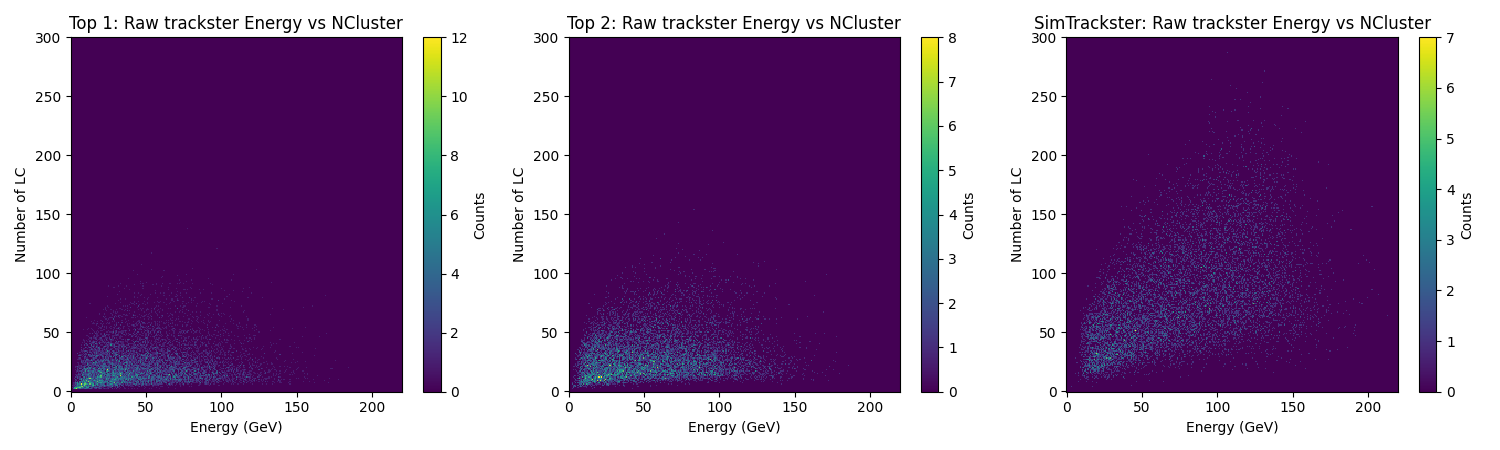

In [558]:
fig , axs = plt.subplots(1,3, figsize=(15,4.5))

h = axs[0].hist2d(ak.to_numpy(baryenergy_raw_tc3d_top1), ak.to_numpy(NClusters_tc3d_top1), bins=300, range=((-0.1,220),(-0.5, 300)))
fig.colorbar(h[3], ax=axs[0], label='Counts')

axs[0].set_ylabel(r'Number of LC')
axs[0].set_xlabel(r'Energy (GeV)')
axs[0].set_title(r'Top 1: Raw trackster Energy vs NCluster')

h = axs[1].hist2d(ak.to_numpy(baryenergy_raw_tc3d_top2) , ak.to_numpy(NClusters_tc3d_top2), bins=300, range=((-0.1,220),(-0.5, 300)))
fig.colorbar(h[3], ax=axs[1], label='Counts')

axs[1].set_ylabel(r'Number of LC')
axs[1].set_xlabel(r'Energy (GeV)')
axs[1].set_title(r'Top 2: Raw trackster Energy vs NCluster')

h = axs[2].hist2d(ak.to_numpy(baryenergy_raw_LC1rm) , ak.to_numpy(NClusters_LC1rm), bins=300, range=((-0.1,220),(-0.5, 300)))
fig.colorbar(h[3], ax=axs[2], label='Counts')

axs[2].set_ylabel(r'Number of LC')
axs[2].set_xlabel(r'Energy (GeV)')
axs[2].set_title(r'SimTrackster: Raw trackster Energy vs NCluster')

plt.tight_layout()
plt.show()

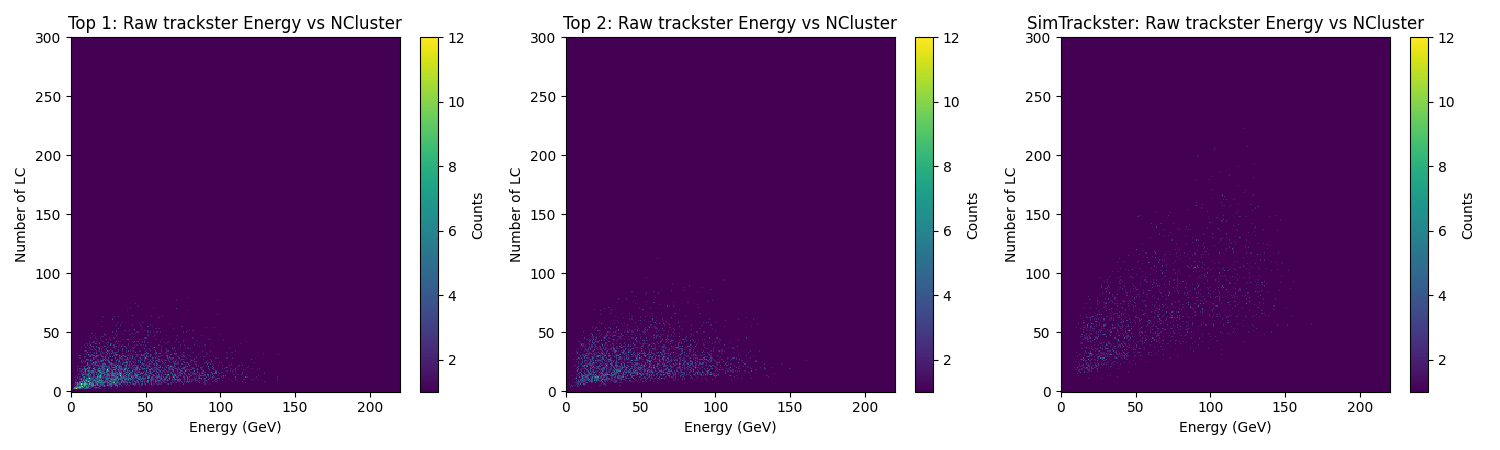

In [682]:
# SAME Z scale

# Compute all histograms' counts first to get global vmin/vmax
datasets = [
    (ak.to_numpy(baryenergy_raw_tc3d_top1), ak.to_numpy(NClusters_tc3d_top1)),
    (ak.to_numpy(baryenergy_raw_tc3d_top2), ak.to_numpy(NClusters_tc3d_top2)),
    (ak.to_numpy(baryenergy_raw_LC1rm), ak.to_numpy(NClusters_LC1rm))
]

all_counts = []
for x, y in datasets:
    counts, _, _ = np.histogram2d(x, y, bins=300, range=[(-0.1, 220), (-0.5, 300)])
    all_counts.append(counts)

# Get global min/max (ignore zeros for min)
vmin = min(c[c > 0].min() for c in all_counts)
vmax = max(c.max() for c in all_counts)

# Now plot with fixed vmin/vmax
fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))

titles = [
    r'Top 1: Raw trackster Energy vs NCluster',
    r'Top 2: Raw trackster Energy vs NCluster',
    r'SimTrackster: Raw trackster Energy vs NCluster'
]

for ax, (x, y), title in zip(axs, datasets, titles):
    h = ax.hist2d(x, y, bins=300, range=[(-0.1, 220), (-0.5, 300)], vmin=vmin, vmax=vmax)
    fig.colorbar(h[3], ax=ax, label='Counts')
    ax.set_ylabel(r'Number of LC')
    ax.set_xlabel(r'Energy (GeV)')
    ax.set_title(title)

plt.tight_layout()
plt.show()

##### Angle plots

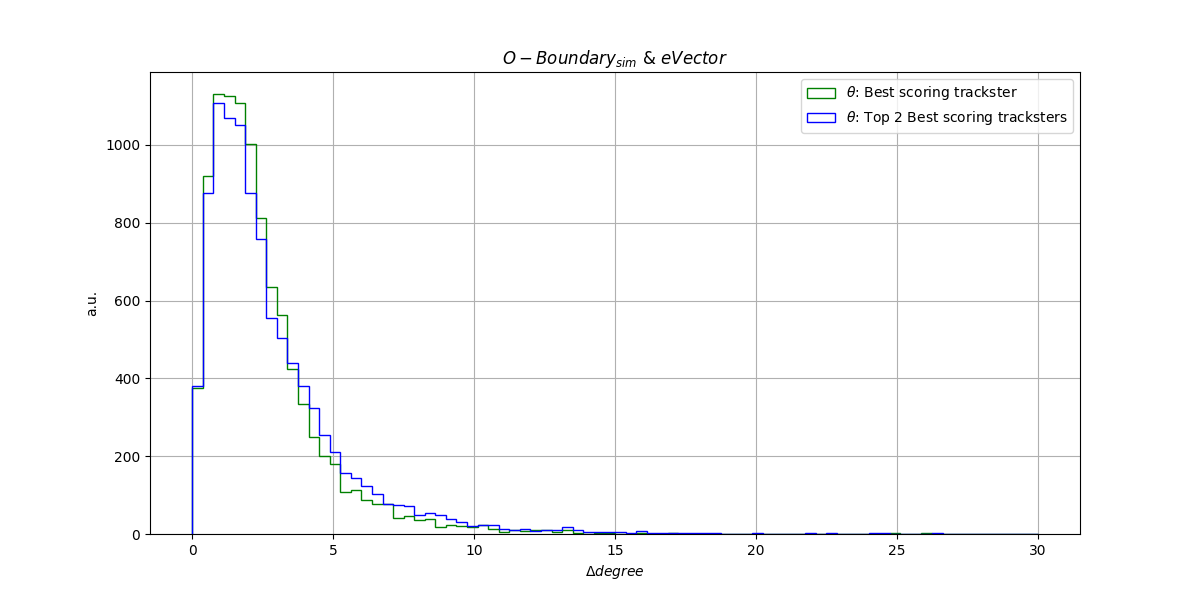

In [591]:
plt.figure(figsize=(12, 6))

plt.hist(theta_1, bins=80, color= 'green',histtype='step' ,alpha = 1, label = r'$\theta$: Best scoring trackster', range = (0, 30) )
plt.hist(theta_2, bins=80,histtype='step', color= 'blue', alpha = 1, label = r'$\theta$: Top 2 Best scoring tracksters', range = (0, 30) )

# plt.hist(theta_3, bins=80,histtype='step', color= 'red', alpha = 1, label = r'$\theta$: Sim trackster', range = (0, 30) )

plt.xlabel(r'$\Delta degree$') 
plt.ylabel('a.u.')
# plt.yscale('log')
plt.title(title_)
plt.legend()
plt.grid()
plt.show()

Filtering out theta>80 from successive plots

##### theta vs Eta

In [696]:
eta_top1 = ak.to_numpy(barycenters_eta_tc3d_ON[sorted_trackster_top1][:, 0])
eta_top2 = ak.to_numpy(eta_vec(v_tc3d_top2_norm))
eta_top3 = ak.to_numpy(eta_vec(v_LC1rm_norm))

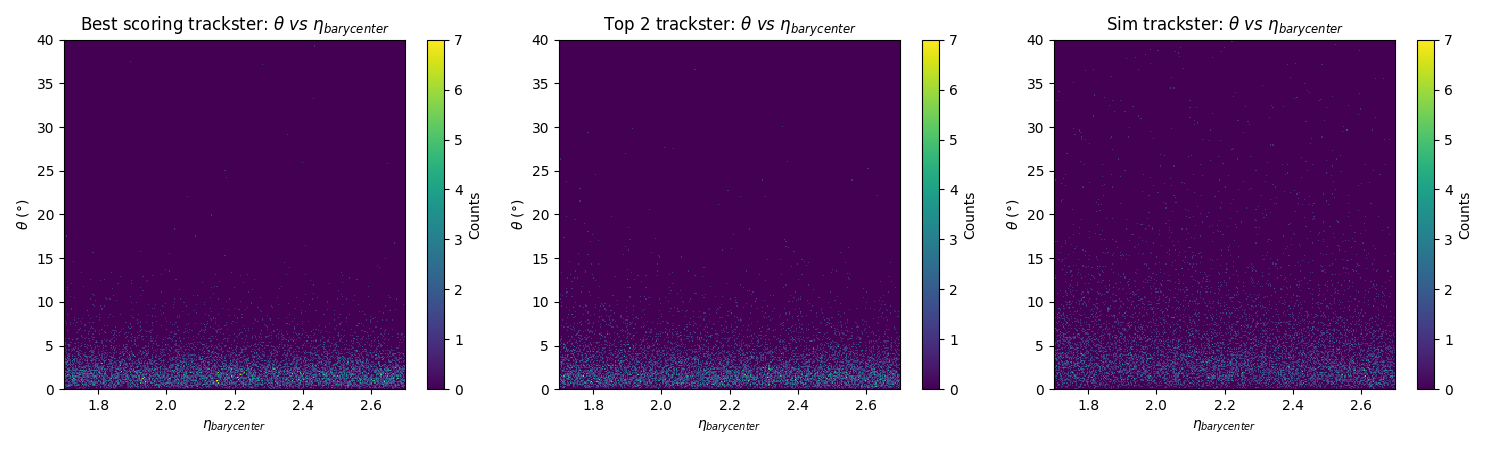

In [699]:
fig , axs = plt.subplots(1,3, figsize=(15,4.5))

h = axs[0].hist2d(eta_top1, theta_1, bins=300, range=((1.7, 2.7),(0,40)))
fig.colorbar(h[3], ax=axs[0], label='Counts')

axs[0].set_xlabel(r'$\eta_{barycenter}$')
axs[0].set_ylabel(r'$\theta\ (\degree)$')
axs[0].set_title(r'Best scoring trackster: $ \theta\ vs\ \eta_{barycenter}$') 

h = axs[1].hist2d(eta_top2, theta_2, bins=300, range=((1.7, 2.7),(0,40)), vmax = 7)
fig.colorbar(h[3], ax=axs[1], label='Counts')

axs[1].set_xlabel(r'$\eta_{barycenter}$')
axs[1].set_ylabel(r'$\theta\ (\degree)$')
axs[1].set_title(r'Top 2 trackster: $ \theta\ vs\ \eta_{barycenter}$') 

h = axs[2].hist2d(eta_top3, theta_3, bins=300, range=((1.7, 2.7),(0,40)), vmax = 7)
fig.colorbar(h[3], ax=axs[2], label='Counts')

axs[2].set_xlabel(r'$\eta_{barycenter}$')
axs[2].set_ylabel(r'$\theta\ (\degree)$')
axs[2].set_title(r'Sim trackster: $ \theta\ vs\ \eta_{barycenter}$') 

plt.tight_layout()
plt.show()

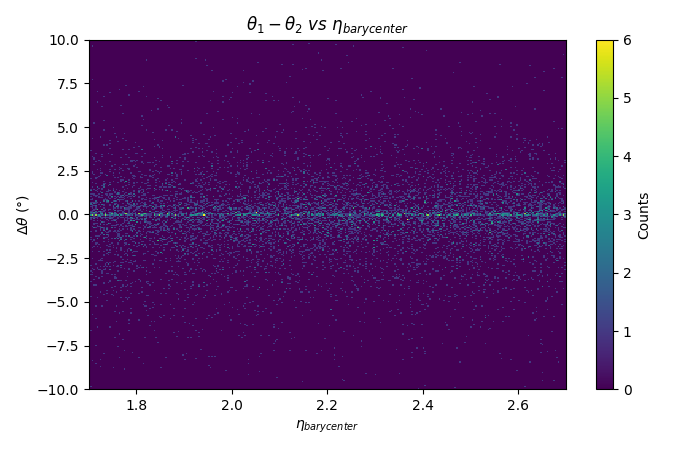

In [881]:
fig , axs = plt.subplots(1,1, figsize=(7,4.5))

h = axs.hist2d(eta_top1, theta_1-theta_2, bins=300, range=((1.7, 2.7),(-10,10)))
fig.colorbar(h[3], ax=axs, label='Counts')

axs.set_xlabel(r'$\eta_{barycenter}$')
axs.set_ylabel(r'$\Delta \theta\ (\degree)$')
axs.set_title(r'$ \theta_1-\theta_2\ vs\ \eta_{barycenter}$') 


plt.tight_layout()
plt.show()

##### multiple plots #6

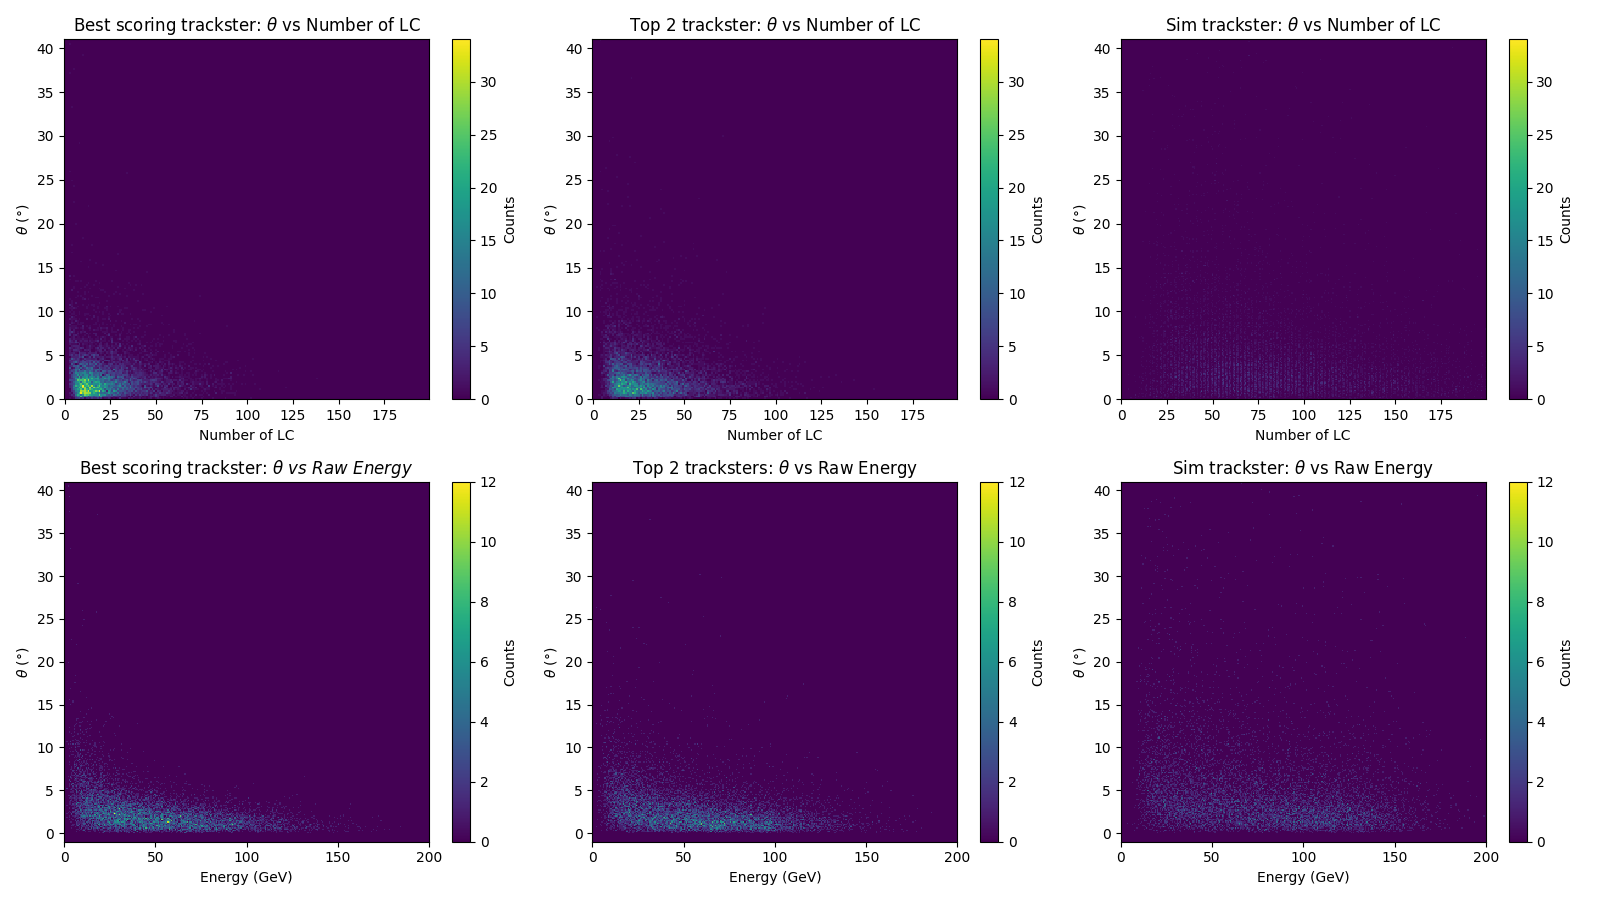

In [702]:
fig , axs = plt.subplots(2,3, figsize=(16,9))

h = axs[0,0].hist2d(ak.to_numpy(NClusters_tc3d_top1), theta_1, bins=200, range = ((-0.5,199.5),(0,41)))
fig.colorbar(h[3], ax=axs[0,0], label='Counts')

axs[0,0].set_xlabel(r'Number of LC')
axs[0,0].set_ylabel(r'$\theta\ (\degree)$')
axs[0,0].set_title(r'Best scoring trackster: $ \theta$ vs Number of LC')

h = axs[0,1].hist2d(ak.to_numpy(NClusters_tc3d_top2), theta_2, bins=200, range = ((-0.5,199.5),(0,41)), vmax = 34)
fig.colorbar(h[3], ax=axs[0,1], label='Counts')

axs[0,1].set_xlabel(r'Number of LC')
axs[0,1].set_ylabel(r'$\theta\ (\degree)$')
axs[0,1].set_title(r'Top 2 trackster: $ \theta$ vs Number of LC')

h = axs[0,2].hist2d(ak.to_numpy(NClusters_LC1rm), theta_3, bins=300, range = ((-0.5,199.5),(0,41)), vmax = 34)
fig.colorbar(h[3], ax=axs[0,2], label='Counts')

axs[0,2].set_xlabel(r'Number of LC')
axs[0,2].set_ylabel(r'$\theta\ (\degree)$')
axs[0,2].set_title(r'Sim trackster: $ \theta$ vs Number of LC')

h = axs[1,0].hist2d(ak.to_numpy(baryenergy_raw_tc3d_top1), theta_1, bins=300, range = ((-0.1,200),((-1,41))))
fig.colorbar(h[3], ax=axs[1,0], label='Counts')

axs[1,0].set_xlabel(r'Energy (GeV)')
axs[1,0].set_ylabel(r'$\theta\ (\degree)$')
axs[1,0].set_title(r'Best scoring trackster: $\theta\ vs\ Raw\ Energy$')

h = axs[1,1].hist2d(ak.to_numpy(baryenergy_raw_tc3d_top2), theta_2, bins=300, range = ((-0.1,200),((-1,41))), vmax = 12)
fig.colorbar(h[3], ax=axs[1,1], label='Counts')

axs[1,1].set_xlabel(r'Energy (GeV)')
axs[1,1].set_ylabel(r'$\theta\ (\degree)$')
axs[1,1].set_title(r'Top 2 tracksters: $\theta$ vs Raw Energy')

h = axs[1,2].hist2d(ak.to_numpy(baryenergy_raw_LC1rm), theta_3, bins=300, range = ((-0.1,200),((-1,41))), vmax = 12)
fig.colorbar(h[3], ax=axs[1,2], label='Counts')

axs[1,2].set_xlabel(r'Energy (GeV)')
axs[1,2].set_ylabel(r'$\theta\ (\degree)$')
axs[1,2].set_title(r'Sim trackster: $\theta$ vs Raw Energy')

plt.tight_layout()
plt.show()

##### multiple plots #4

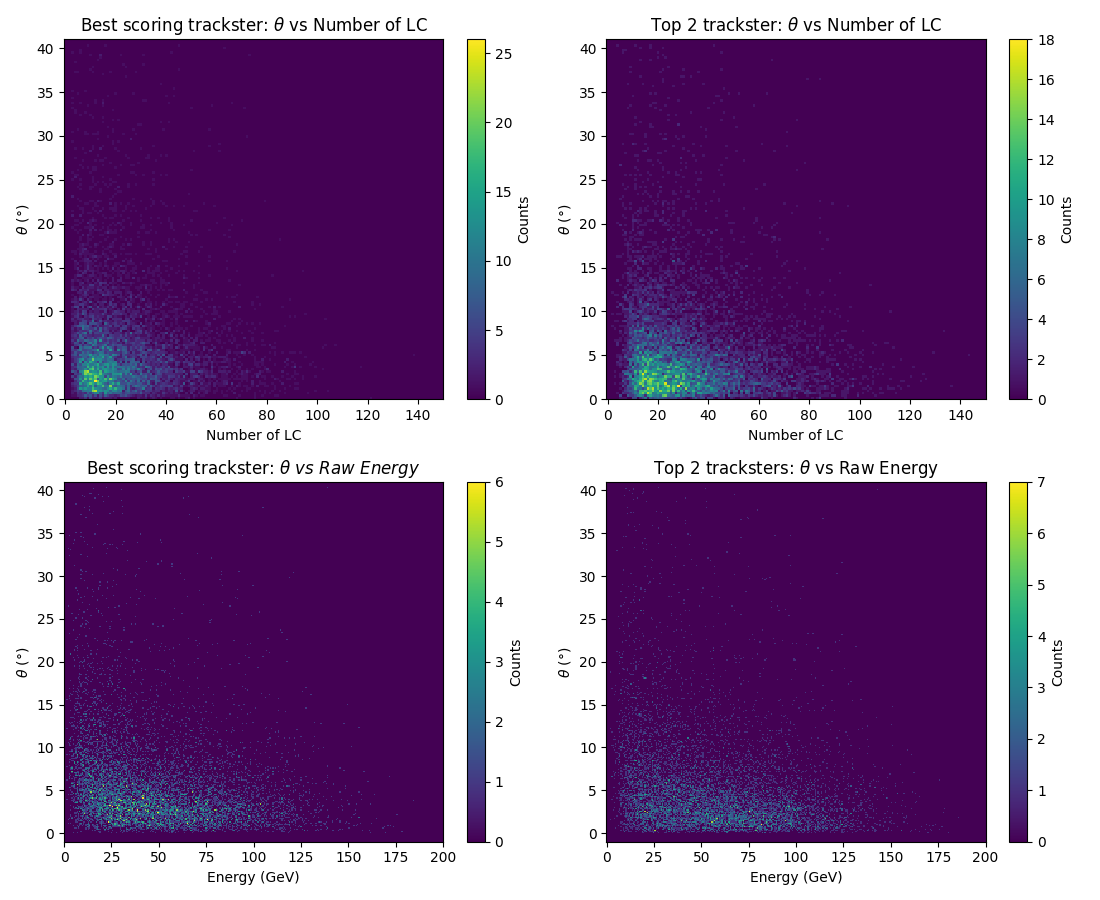

In [571]:
fig , axs = plt.subplots(2,2, figsize=(11,9))

h = axs[0,0].hist2d(ak.to_numpy(NClusters_tc3d_top1), theta_1, bins=150, range = ((-0.5,150),(0,41)))
fig.colorbar(h[3], ax=axs[0,0], label='Counts')

axs[0,0].set_xlabel(r'Number of LC')
axs[0,0].set_ylabel(r'$\theta\ (\degree)$')
axs[0,0].set_title(r'Best scoring trackster: $ \theta$ vs Number of LC')

h = axs[0,1].hist2d(ak.to_numpy(NClusters_tc3d_top2), theta_2, bins=150, range = ((-0.5,150),(0,41)))
fig.colorbar(h[3], ax=axs[0,1], label='Counts')

axs[0,1].set_xlabel(r'Number of LC')
axs[0,1].set_ylabel(r'$\theta\ (\degree)$')
axs[0,1].set_title(r'Top 2 trackster: $ \theta$ vs Number of LC')


h = axs[1,0].hist2d(ak.to_numpy(baryenergy_raw_tc3d_top1), theta_1, bins=300, range = ((-0.1,200),((-1,41))))
fig.colorbar(h[3], ax=axs[1,0], label='Counts')

axs[1,0].set_xlabel(r'Energy (GeV)')
axs[1,0].set_ylabel(r'$\theta\ (\degree)$')
axs[1,0].set_title(r'Best scoring trackster: $\theta\ vs\ Raw\ Energy$')

h = axs[1,1].hist2d(ak.to_numpy(baryenergy_raw_tc3d_top2), theta_2, bins=300, range = ((-0.1,200),((-1,41))))
fig.colorbar(h[3], ax=axs[1,1], label='Counts')

axs[1,1].set_xlabel(r'Energy (GeV)')
axs[1,1].set_ylabel(r'$\theta\ (\degree)$')
axs[1,1].set_title(r'Top 2 tracksters: $\theta$ vs Raw Energy')


plt.tight_layout()
plt.show()

In [876]:
plt.close()

##### theta vs Energy

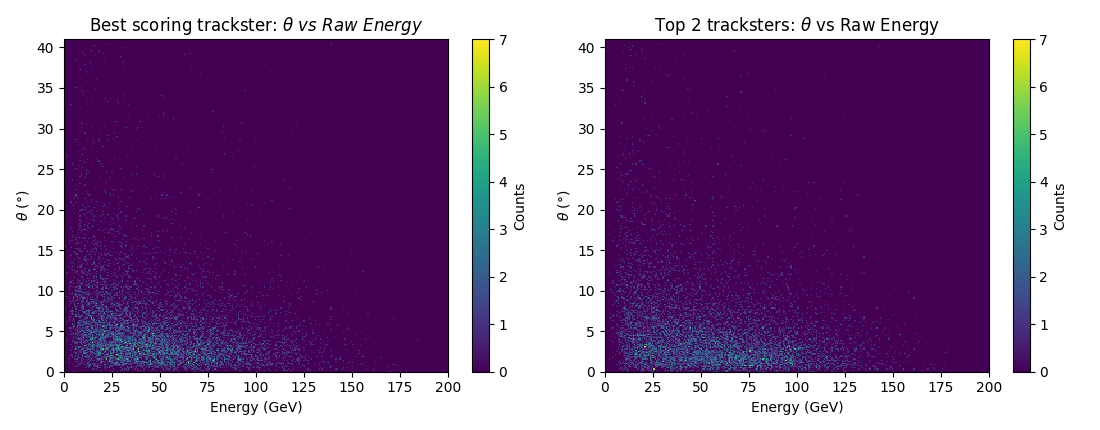

In [691]:
fig , axs = plt.subplots(1,2, figsize=(11,4.3))

h = axs[0].hist2d(ak.to_numpy(baryenergy_raw_tc3d_top1), theta_1, bins=300, range = ((0,200),((-0,41))), vmax = 7)
fig.colorbar(h[3], ax=axs[0], label='Counts')

axs[0].set_xlabel(r'Energy (GeV)')
axs[0].set_ylabel(r'$\theta\ (\degree)$')
axs[0].set_title(r'Best scoring trackster: $\theta\ vs\ Raw\ Energy$')

h = axs[1].hist2d(ak.to_numpy(baryenergy_raw_tc3d_top2), theta_2, bins=300, range = ((0,200),((-0,41))))
fig.colorbar(h[3], ax=axs[1], label='Counts')

axs[1].set_xlabel(r'Energy (GeV)')
axs[1].set_ylabel(r'$\theta\ (\degree)$')
axs[1].set_title(r'Top 2 tracksters: $\theta$ vs Raw Energy')

# h = axs[2].hist2d(ak.to_numpy(baryenergy_raw_LC1rm), theta_2, bins=300, range = ((0,185),((-1,31))))
# fig.colorbar(h[3], ax=axs[2], label='Counts')

# axs[2].set_xlabel(r'Energy (GeV)')
# axs[2].set_ylabel(r'$\theta\ (\degree)$')
# axs[2].set_title(r'Sim trackster: $\theta$ vs Raw Energy')

plt.tight_layout()
plt.show()

##### theta vs NCluster

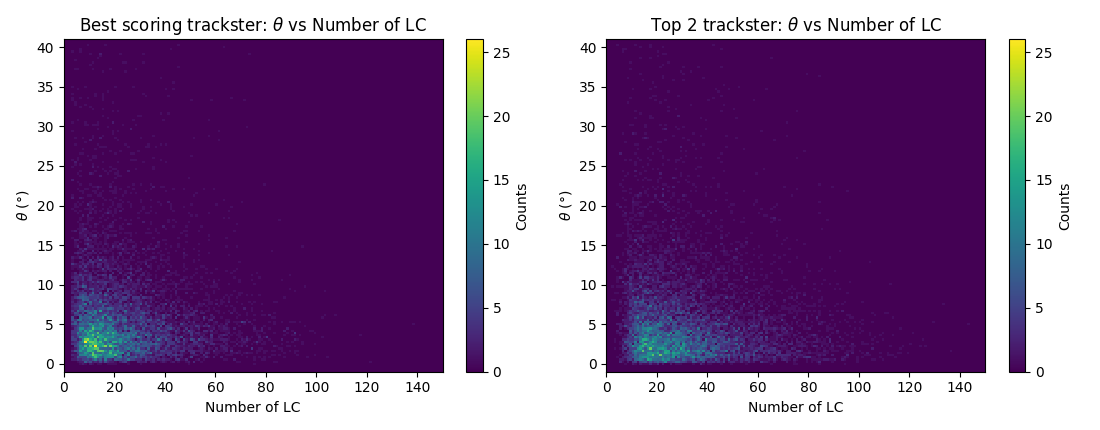

In [687]:
fig , axs = plt.subplots(1,2, figsize=(11,4.3))

h = axs[0].hist2d(ak.to_numpy(NClusters_tc3d_top1), theta_1, bins=150, range = ((0,150),(-1,41)), vmax =26)
fig.colorbar(h[3], ax=axs[0], label='Counts')

axs[0].set_xlabel(r'Number of LC')
axs[0].set_ylabel(r'$\theta\ (\degree)$')
axs[0].set_title(r'Best scoring trackster: $ \theta$ vs Number of LC')

h = axs[1].hist2d(ak.to_numpy(NClusters_tc3d_top2), theta_2, bins=150, range = ((0,150),(-1,41)), vmax= 26)
fig.colorbar(h[3], ax=axs[1], label='Counts')

axs[1].set_xlabel(r'Number of LC')
axs[1].set_ylabel(r'$\theta\ (\degree)$')
axs[1].set_title(r'Top 2 trackster: $ \theta$ vs Number of LC')

# h = axs[2].hist2d(ak.to_numpy(NClusters_LC1rm), theta_2, bins=300, range = ((0,155),(0,31)))
# fig.colorbar(h[3], ax=axs[2], label='Counts')

# axs[2].set_xlabel(r'Number of LC')
# axs[2].set_ylabel(r'$\theta\ (\degree)$')
# axs[2].set_title(r'Sim trackster: $ \theta$ vs Number of LC')

plt.tight_layout()
plt.show()

##### theta vs Explained Variance

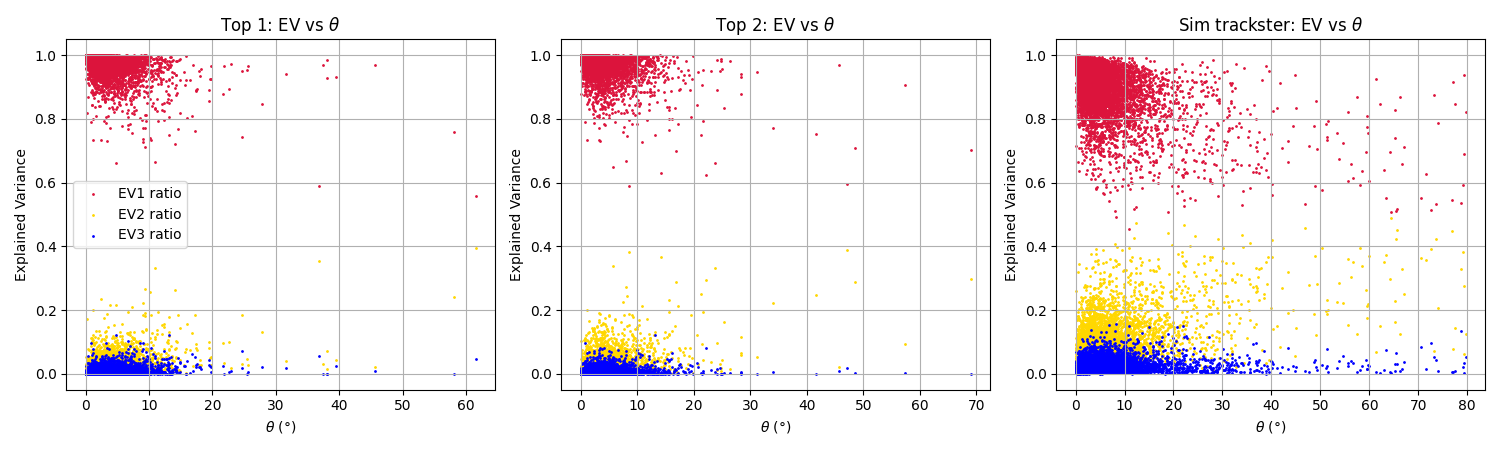

In [525]:
fig , axs = plt.subplots(1,3, figsize=(15,4.5))

above_x_mask = theta_1>80
axs[0].scatter(theta_1[~above_x_mask], EV_tc3d_top1[:,0][~above_x_mask] , s = 1 , color = 'crimson', label = 'EV1 ratio')
axs[0].scatter(theta_1[~above_x_mask], EV_tc3d_top1[:,1][~above_x_mask] , s = 1 , color = 'gold', label = 'EV2 ratio')
axs[0].scatter(theta_1[~above_x_mask], EV_tc3d_top1[:,2][~above_x_mask] , s = 1, color = 'blue', label = 'EV3 ratio')

axs[0].set_ylabel(r'Explained Variance')
axs[0].set_xlabel(r'$\theta\ (\degree)$')
axs[0].set_title(r'Top 1: EV vs $ \theta$') 
axs[0].grid()

above_x_mask = theta_2>80
axs[1].scatter(theta_2[~above_x_mask], EV_tc3d_top2[:,0][~above_x_mask] , s = 1 , color = 'crimson', label = 'EV1 ratio')
axs[1].scatter(theta_2[~above_x_mask], EV_tc3d_top2[:,1][~above_x_mask] , s = 1 , color = 'gold', label = 'EV2 ratio')
axs[1].scatter(theta_2[~above_x_mask], EV_tc3d_top2[:,2][~above_x_mask] , s = 1, color = 'blue', label = 'EV3 ratio')

axs[1].set_ylabel(r'Explained Variance')
axs[1].set_xlabel(r'$\theta\ (\degree)$')
axs[1].set_title(r'Top 2: EV vs $ \theta$') 

axs[1].grid()

above_x_mask = theta_3>80
axs[2].scatter(theta_3[~above_x_mask], EV_LC1rm[:,0][~above_x_mask] , s = 1 , color = 'crimson', label = 'EV1 ratio')
axs[2].scatter(theta_3[~above_x_mask], EV_LC1rm[:,1][~above_x_mask] , s = 1 , color = 'gold', label = 'EV2 ratio')
axs[2].scatter(theta_3[~above_x_mask], EV_LC1rm[:,2][~above_x_mask] , s = 1, color = 'blue', label = 'EV3 ratio')

axs[2].set_ylabel(r'Explained Variance')
axs[2].set_xlabel(r'$\theta\ (\degree)$')
axs[2].set_title(r'Sim trackster: EV vs $ \theta$') 

axs[2].grid()

axs[0].legend()
plt.tight_layout()
plt.show()

## TC

#### Selecting PCA Eigenvector

In [781]:
# Best scoring tracksters:
sorted_trackster_tc_top1 = tc_simToReco_SC[ak.argsort(tc_simToReco_SC_score)][:,:1]
barycenter_tc_top1 = [bary_x_tc_ON[sorted_trackster_tc_top1] , bary_y_tc_ON[sorted_trackster_tc_top1] , bary_z_tc_ON[sorted_trackster_tc_top1]]
evector_tc_top1 = [evector_x_tc_ON[sorted_trackster_tc_top1] , evector_y_tc_ON[sorted_trackster_tc_top1] , evector_z_tc_ON[sorted_trackster_tc_top1]]
baryenergy_raw_tc_top1 = baryenergy_raw_tc_ON[sorted_trackster_tc_top1][:,0]
NClusters_tc_top1 = ak.sum(ak.num(vertices_indexes_tc_ON[sorted_trackster_tc_top1], axis=-1), axis = 1)

EV_sum_tc = (EV_tc_ON["EV1"][sorted_trackster_tc_top1]+EV_tc_ON["EV2"][sorted_trackster_tc_top1]+EV_tc_ON["EV3"][sorted_trackster_tc_top1])
EV_tc_top1 = np.stack([EV_tc_ON["EV1"][sorted_trackster_tc_top1][:,0]/EV_sum_tc[:,0] , EV_tc_ON["EV2"][sorted_trackster_tc_top1][:,0]/EV_sum_tc[:,0] , EV_tc_ON["EV3"][sorted_trackster_tc_top1][:,0]/EV_sum_tc[:,0]], axis = -1)


# Highest (top 2) scoring tracksters:
sorted_trackster_tc_top2 = tc_simToReco_SC[ak.argsort(tc_simToReco_SC_score)][:,:2]

In [790]:
Evts = len(x_SC_ON[:10000])
# trackster_arr = []
baryenergy_raw_tc_top2 = np.zeros(Evts)
EV_tc_top2 = np.zeros((Evts,3))
NClusters_tc_top2 = np.zeros(Evts)
evector_tc_top2 = np.zeros((Evts,3))
bary_tc_top2 = np.zeros((Evts,3))

for event in range(Evts):
    layer_clusters = [
        LayerClusters(x_tc_ON[sorted_trackster_tc_top2][event], 
                     y_tc_ON[sorted_trackster_tc_top2][event], 
                     z_tc_ON[sorted_trackster_tc_top2][event], 
                     energy_tc_ON[sorted_trackster_tc_top2][event])
    ]
    
    trackster_tc = Trackster()
    trackster_tc._vertices = ak.flatten(vertices_indexes_tc_ON[sorted_trackster_tc_top2], axis = -1)[event]
    assign_pca_to_tracksters([trackster_tc], layer_clusters, energy_weight=True)#, clean=False)

    # Calculating explained variance
    total_variance = np.sum(trackster_tc._eigenvalues)
    explained_variance_ratio = trackster_tc._eigenvalues[::-1] / total_variance if total_variance > 0 else np.zeros(3)
    
    baryenergy_raw_tc_top2[event] = trackster_tc._raw_energy
    NClusters_tc_top2[event] = trackster_tc._NCLusters_for_PCA
    evector_tc_top2[event] = trackster_tc._eigenvectors[:,2]
    bary_tc_top2[event] = [trackster_tc._barycenter.x , trackster_tc._barycenter.y , trackster_tc._barycenter.z]
    EV_tc_top2[event] = explained_variance_ratio 
    # trackster_arr.append(trackster_tc)

##### Defining unit Vectors

In [791]:
# Highest scored / Weighted trackster
u_tc_top1 = ak.Array(np.stack([evector_tc_top1[0] , evector_tc_top1[1] , evector_tc_top1[2]], axis = -1))[:,0]
v_tc_top1 = ak.Array(np.stack([barycenter_tc_top1[0] , barycenter_tc_top1[1] , barycenter_tc_top1[2]], axis = -1))[:,0]
v_tc_top1_norm = v_tc_top1/np.linalg.norm(v_tc_top1, axis = 1, keepdims=True) 

# Top 2 trackster
u_tc_top2 = evector_tc_top2
v_tc_top2_norm = bary_tc_top2/np.linalg.norm(bary_tc_top2, axis = 1, keepdims=True) 

#### Visulation

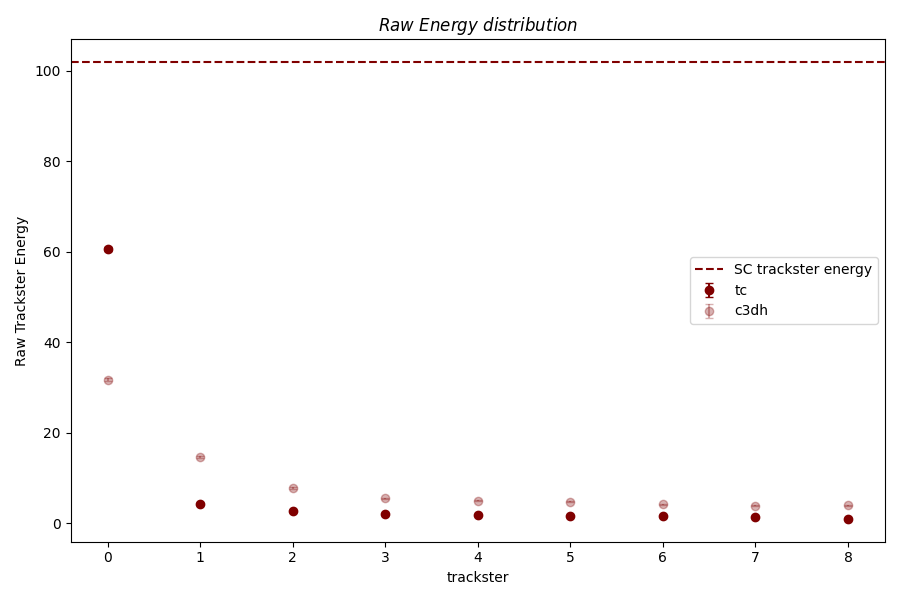

In [832]:
fig , axs = plt.subplots(1,1, figsize=(9,6))
x = -9
Z_tc = baryenergy_raw_tc_ON[ak.argsort(tc_simToReco_SC_score)]
means_tc = ak.mean(Z_tc, axis=0)[:-x]
errors_tc = (ak.std(Z_tc, axis=0) / np.sqrt(ak.count(Z_tc, axis=0)))[:-x]
axs.errorbar(np.arange(len(means_tc)), means_tc, yerr=errors_tc, fmt='o', capsize=3, color= 'maroon', label= 'tc')

Z = baryenergy_raw_tc3d_ON[ak.argsort(c3dh_simToReco_SC_score)]
means = ak.mean(Z, axis=0)[:-x]
errors = (ak.std(Z, axis=0) / np.sqrt(ak.count(Z, axis=0)))[:-x]
axs.errorbar(np.arange(len(means)), means, yerr=errors, fmt='o', capsize=3, color= 'maroon', alpha = 0.3, label = 'c3dh')

axs.axhline(y=ak.mean(baryenergy_raw_SC_ON), color='maroon', linestyle='--', label=r'SC trackster energy')


axs.set_ylabel(r'Raw Trackster Energy')
axs.set_xlabel(r'trackster')
axs.set_title(r'$Raw\ Energy\ distribution$')


axs.legend()
plt.tight_layout()
plt.show()

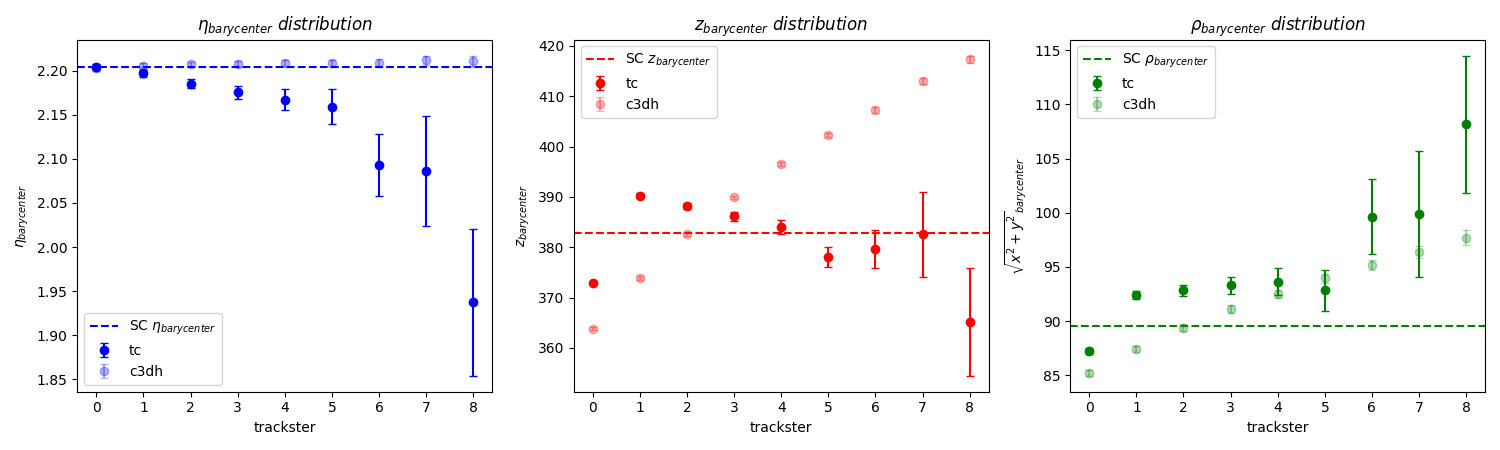

In [822]:
fig , axs = plt.subplots(1,3, figsize=(15,4.5))
x = -9
X_tc = np.sqrt(bary_y_tc_ON[ak.argsort(tc_simToReco_SC_score)]**2+bary_x_tc_ON[ak.argsort(tc_simToReco_SC_score)]**2)
means_tc = ak.mean(X_tc, axis=0)[:-x]
errors_tc = (ak.std(X_tc, axis=0) / np.sqrt(ak.count(X_tc, axis=0)))[:-x]
axs[2].errorbar(np.arange(len(means_tc)), means_tc, yerr=errors_tc, fmt='o', capsize=3, color= 'green', label= 'tc')

axs[2].set_ylabel(r'$\sqrt{x^2+y^2}_{barycenter}$')
axs[2].set_xlabel(r'trackster')
axs[2].set_title(r'$\rho_{barycenter}\ distribution$') 

Y_tc = bary_z_tc_ON[ak.argsort(tc_simToReco_SC_score)]
means_tc = ak.mean(Y_tc, axis=0)[:-x]
errors_tc = (ak.std(Y_tc, axis=0) / np.sqrt(ak.count(Y_tc, axis=0)))[:-x]
axs[1].errorbar(np.arange(len(means_tc)), means_tc, yerr=errors_tc, fmt='o', capsize=3, color= 'red', label= 'tc')

axs[1].set_ylabel(r'$z_{barycenter}$')
axs[1].set_xlabel(r'trackster')
axs[1].set_title(r'$z_{barycenter}\ distribution$')

Z_tc = barycenters_eta_tc_ON[ak.argsort(tc_simToReco_SC_score)]
means_tc = ak.mean(Z_tc, axis=0)[:-x]
errors_tc = (ak.std(Z_tc, axis=0) / np.sqrt(ak.count(Z_tc, axis=0)))[:-x]
axs[0].errorbar(np.arange(len(means_tc)), means_tc, yerr=errors_tc, fmt='o', capsize=3, color= 'blue', label= 'tc')

axs[0].set_ylabel(r'$\eta_{barycenter}$')
axs[0].set_xlabel(r'trackster')
axs[0].set_title(r'$\eta_{barycenter}\ distribution$')

## C3DH
X = np.sqrt(bary_y_tc3d_ON[ak.argsort(c3dh_simToReco_SC_score)]**2+bary_x_tc3d_ON[ak.argsort(c3dh_simToReco_SC_score)]**2)
means = ak.mean(X, axis=0)[:-x]
errors = (ak.std(X, axis=0) / np.sqrt(ak.count(X, axis=0)))[:-x]
axs[2].errorbar(np.arange(len(means)), means, yerr=errors, fmt='o', capsize=3, color= 'green', alpha = 0.3, label = 'c3dh')

Y = bary_z_tc3d_ON[ak.argsort(c3dh_simToReco_SC_score)]
means = ak.mean(Y, axis=0)[:-x]
errors = (ak.std(Y, axis=0) / np.sqrt(ak.count(Y, axis=0)))[:-x]
axs[1].errorbar(np.arange(len(means)), means, yerr=errors, fmt='o', capsize=3, color= 'red', alpha = 0.3, label = 'c3dh')

Z = barycenters_eta_tc3d_ON[ak.argsort(c3dh_simToReco_SC_score)]
means = ak.mean(Z, axis=0)[:-x]
errors = (ak.std(Z, axis=0) / np.sqrt(ak.count(Z, axis=0)))[:-x]
axs[0].errorbar(np.arange(len(means)), means, yerr=errors, fmt='o', capsize=3, color= 'blue', alpha = 0.3, label = 'c3dh')

axs[0].axhline(y=ak.mean(barycenters_eta_SC_ON), color='b', linestyle='--', label=r'SC $\eta_{barycenter}$')
axs[1].axhline(y=ak.mean(bary_z_SC_ON), color='r', linestyle='--', label=r'SC $z_{barycenter}$')
axs[2].axhline(y=ak.mean(np.sqrt(bary_y_SC_ON**2+bary_x_SC_ON**2)), color='g', linestyle='--', label=r'SC $\rho_{barycenter}$')

axs[0].legend()
axs[1].legend()
axs[2].legend()
plt.tight_layout()
plt.show()

#### Plots

##### Energy vs NCluster

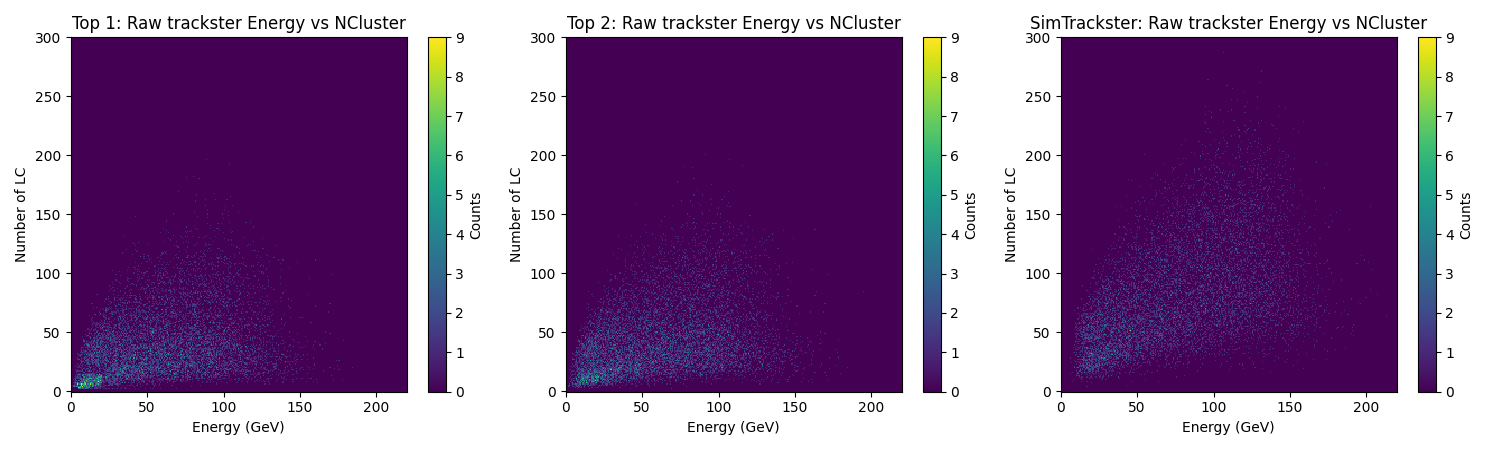

In [836]:
fig , axs = plt.subplots(1,3, figsize=(15,4.5))

h = axs[0].hist2d(ak.to_numpy(baryenergy_raw_tc_top1), ak.to_numpy(NClusters_tc_top1), bins=300, range=((-0.1,220),(-0.5, 300)))
fig.colorbar(h[3], ax=axs[0], label='Counts')

axs[0].set_ylabel(r'Number of LC')
axs[0].set_xlabel(r'Energy (GeV)')
axs[0].set_title(r'Top 1: Raw trackster Energy vs NCluster')

h = axs[1].hist2d(ak.to_numpy(baryenergy_raw_tc_top2) , ak.to_numpy(NClusters_tc_top2), bins=300, range=((-0.1,220),(-0.5, 300)), vmax = 9)
fig.colorbar(h[3], ax=axs[1], label='Counts')

axs[1].set_ylabel(r'Number of LC')
axs[1].set_xlabel(r'Energy (GeV)')
axs[1].set_title(r'Top 2: Raw trackster Energy vs NCluster')

h = axs[2].hist2d(ak.to_numpy(baryenergy_raw_LC1rm) , ak.to_numpy(NClusters_LC1rm), bins=300, range=((-0.1,220),(-0.5, 300)), vmax = 9)
fig.colorbar(h[3], ax=axs[2], label='Counts')

axs[2].set_ylabel(r'Number of LC')
axs[2].set_xlabel(r'Energy (GeV)')
axs[2].set_title(r'SimTrackster: Raw trackster Energy vs NCluster')

plt.tight_layout()
plt.show()

##### Select one of the angles to study

In [867]:
## Angle bw SC and tc3d eigenvector

# title_ = r'$ eVector_{sim}\ &\ eVector_{tc} $'
# cos_theta_1 = np.sum(abs(u_tc_top1*u_LC1rm), axis = 1)
# theta_1 = ak.to_numpy(np.arccos(np.clip(cos_theta_1, -1.0, 1.0))*180/np.pi)

# cos_theta_2 = np.sum(abs(u_tc_top2*u_LC1rm), axis = 1)
# theta_2 = ak.to_numpy(np.arccos(cos_theta_2)*180/np.pi)

# ---------------------- OR ------------------------------
## Angle bw 000_to_SC_boundary and eigenvector

# title_ = r'$ O-Boundary_{sim}\ &\ eVector $'
# cos_theta_1 = np.sum(abs(u_tc_top1*boundary_norm), axis = 1)
# theta_1 = ak.to_numpy(np.arccos(np.clip(cos_theta_1, -1.0, 1.0))*180/np.pi)

# cos_theta_2 = np.sum(abs(u_tc_top2*boundary_norm), axis = 1)
# theta_2 = ak.to_numpy(np.arccos(cos_theta_2)*180/np.pi)

# cos_theta_3 = np.sum(abs(u_LC1rm*boundary_norm), axis = 1)
# theta_3 = ak.to_numpy(np.arccos(cos_theta_3)*180/np.pi)

# ---------------------- OR ------------------------------
## Angle bw 000_to_SC_bary and eigenvector

# title_ = r'$ O-Barycenter_{sim}\ &\ eVector $'
# cos_theta_1 = np.sum(abs(u_tc3d_top1*v_LC1rm_norm), axis = 1)
# theta_1 = ak.to_numpy(np.arccos(np.clip(cos_theta_1, -1.0, 1.0))*180/np.pi)

# cos_theta_2 = np.sum(abs(u_tc3d_top2*v_LC1rm_norm), axis = 1)
# theta_2 = ak.to_numpy(np.arccos(cos_theta_2)*180/np.pi)

# cos_theta_3 = np.sum(abs(u_LC1rm*v_LC1rm_norm), axis = 1)
# theta_3 = ak.to_numpy(np.arccos(cos_theta_3)*180/np.pi)

# ---------------------- OR ------------------------------
## Angle bw SC_bound_to_SC_bary and eigenvector

title_ = r'$ Boundary-Barycenter_{sim}\ &\ eVector $'
cos_theta_1 = np.sum(abs(u_tc3d_top1*(bary_LC1rm-boundary)/np.linalg.norm(bary_LC1rm-boundary, axis = -1, keepdims=True)), axis = 1)
theta_1 = ak.to_numpy(np.arccos(np.clip(cos_theta_1, -1.0, 1.0))*180/np.pi)

cos_theta_2 = np.sum(abs(u_tc3d_top2*(bary_LC1rm-boundary)/np.linalg.norm(bary_LC1rm-boundary, axis = -1, keepdims=True)), axis = 1)
theta_2 = ak.to_numpy(np.arccos(cos_theta_2)*180/np.pi)

cos_theta_3 = np.sum(abs(u_LC1rm*(bary_LC1rm-boundary)/np.linalg.norm(bary_LC1rm-boundary, axis = -1, keepdims=True)), axis = 1)
theta_3 = ak.to_numpy(np.arccos(cos_theta_3)*180/np.pi)

###### Angle plots

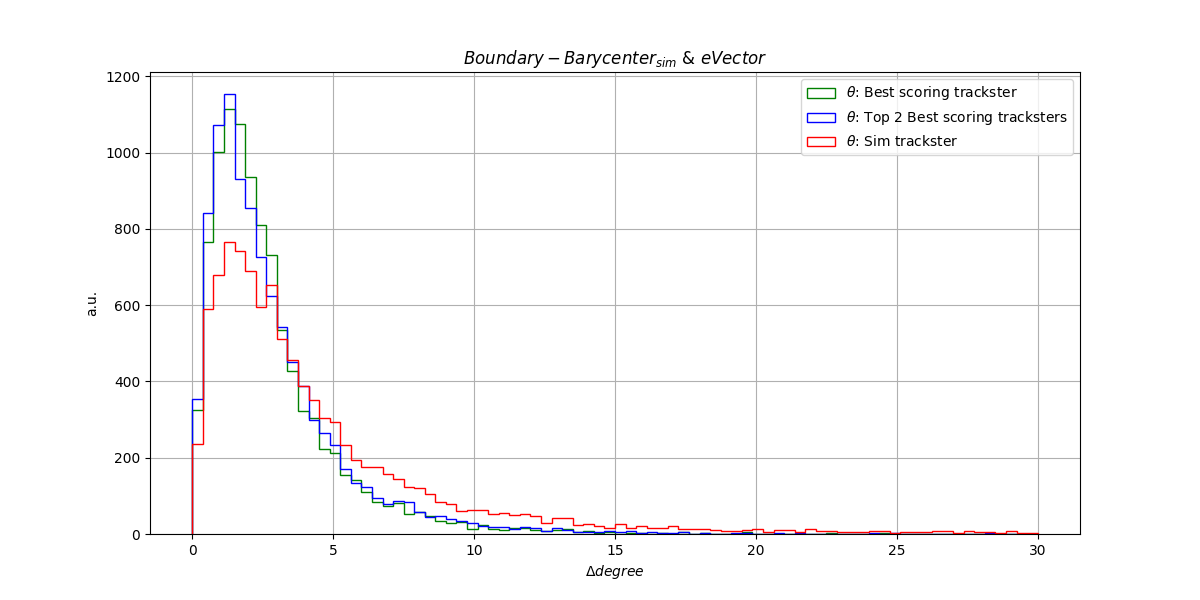

In [869]:
plt.figure(figsize=(12, 6))

plt.hist(theta_1, bins=80, color= 'green',histtype='step' ,alpha = 1, label = r'$\theta$: Best scoring trackster',  range = (0, 30))# ,hatch= '//')
plt.hist(theta_2, bins=80,histtype='step', color= 'blue', alpha = 1, label = r'$\theta$: Top 2 Best scoring tracksters', range = (0, 30) )

plt.hist(theta_3, bins=80,histtype='step', color= 'red', alpha = 1, label = r'$\theta$: Sim trackster', range = (0, 30) )

plt.xlabel(r'$\Delta degree$') 
plt.ylabel('a.u.')
# plt.yscale('log')
plt.title(title_)
plt.legend()
plt.grid()
plt.show()

Filtering out theta>80 from successive plots

###### theta vs Eta

In [856]:
eta_top1 = ak.to_numpy(barycenters_eta_tc_ON[sorted_trackster_tc_top1][:, 0])
eta_top2 = ak.to_numpy(eta_vec(v_tc_top2_norm))
eta_top3 = ak.to_numpy(eta_vec(v_LC1rm_norm))

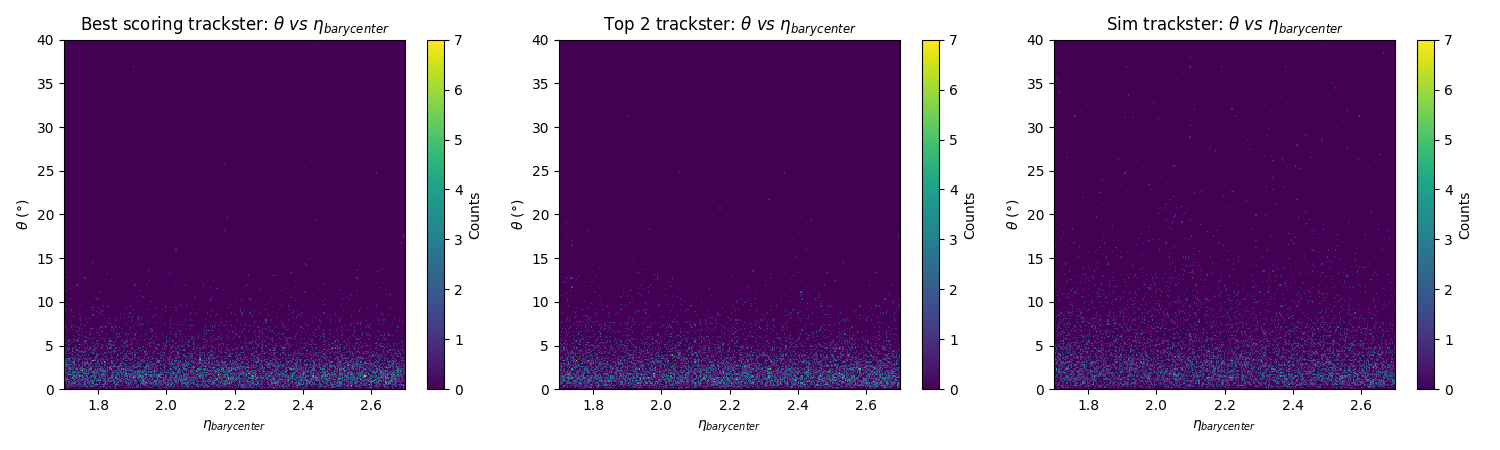

In [871]:
fig , axs = plt.subplots(1,3, figsize=(15,4.5))

h = axs[0].hist2d(eta_top1, theta_1, bins=300, range=((1.7, 2.7),(0,40)))
fig.colorbar(h[3], ax=axs[0], label='Counts')

axs[0].set_xlabel(r'$\eta_{barycenter}$')
axs[0].set_ylabel(r'$\theta\ (\degree)$')
axs[0].set_title(r'Best scoring trackster: $ \theta\ vs\ \eta_{barycenter}$') 

h = axs[1].hist2d(eta_top2, theta_2, bins=300, range=((1.7, 2.7),(0,40)), vmax = 7)
fig.colorbar(h[3], ax=axs[1], label='Counts')

axs[1].set_xlabel(r'$\eta_{barycenter}$')
axs[1].set_ylabel(r'$\theta\ (\degree)$')
axs[1].set_title(r'Top 2 trackster: $ \theta\ vs\ \eta_{barycenter}$') 

h = axs[2].hist2d(eta_top3, theta_3, bins=300, range=((1.7, 2.7),(0,40)), vmax = 7)
fig.colorbar(h[3], ax=axs[2], label='Counts')

axs[2].set_xlabel(r'$\eta_{barycenter}$')
axs[2].set_ylabel(r'$\theta\ (\degree)$')
axs[2].set_title(r'Sim trackster: $ \theta\ vs\ \eta_{barycenter}$') 

plt.tight_layout()
plt.show()

###### multiple plots #6

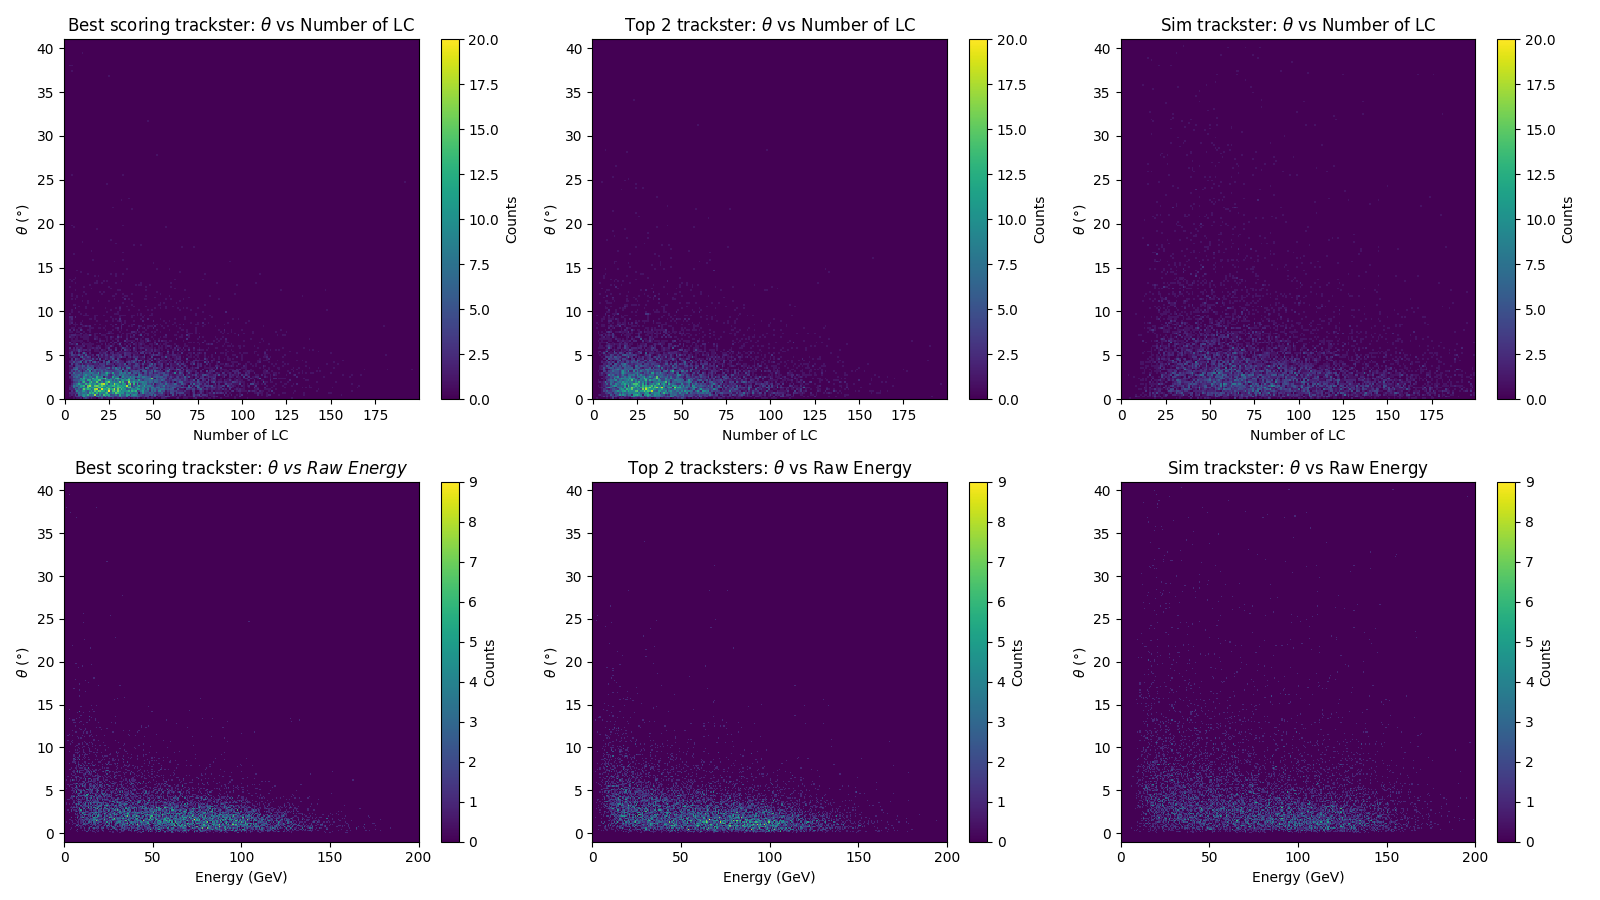

In [874]:
fig , axs = plt.subplots(2,3, figsize=(16,9))

h = axs[0,0].hist2d(ak.to_numpy(NClusters_tc_top1), theta_1, bins=200, range = ((-0.5,199.5),(0,41)))
fig.colorbar(h[3], ax=axs[0,0], label='Counts')

axs[0,0].set_xlabel(r'Number of LC')
axs[0,0].set_ylabel(r'$\theta\ (\degree)$')
axs[0,0].set_title(r'Best scoring trackster: $ \theta$ vs Number of LC')

h = axs[0,1].hist2d(ak.to_numpy(NClusters_tc_top2), theta_2, bins=200, range = ((-0.5,199.5),(0,41)), vmax =20)
fig.colorbar(h[3], ax=axs[0,1], label='Counts')

axs[0,1].set_xlabel(r'Number of LC')
axs[0,1].set_ylabel(r'$\theta\ (\degree)$')
axs[0,1].set_title(r'Top 2 trackster: $ \theta$ vs Number of LC')

h = axs[0,2].hist2d(ak.to_numpy(NClusters_LC1rm), theta_3, bins=200, range = ((-0.5,199.5),(0,41)), vmax =20)
fig.colorbar(h[3], ax=axs[0,2], label='Counts')

axs[0,2].set_xlabel(r'Number of LC')
axs[0,2].set_ylabel(r'$\theta\ (\degree)$')
axs[0,2].set_title(r'Sim trackster: $ \theta$ vs Number of LC')

h = axs[1,0].hist2d(ak.to_numpy(baryenergy_raw_tc_top1), theta_1, bins=300, range = ((-0.1,200),((-1,41))))
fig.colorbar(h[3], ax=axs[1,0], label='Counts')

axs[1,0].set_xlabel(r'Energy (GeV)')
axs[1,0].set_ylabel(r'$\theta\ (\degree)$')
axs[1,0].set_title(r'Best scoring trackster: $\theta\ vs\ Raw\ Energy$')

h = axs[1,1].hist2d(ak.to_numpy(baryenergy_raw_tc_top2), theta_2, bins=300, range = ((-0.1,200),((-1,41))), vmax =9)
fig.colorbar(h[3], ax=axs[1,1], label='Counts')

axs[1,1].set_xlabel(r'Energy (GeV)')
axs[1,1].set_ylabel(r'$\theta\ (\degree)$')
axs[1,1].set_title(r'Top 2 tracksters: $\theta$ vs Raw Energy')

h = axs[1,2].hist2d(ak.to_numpy(baryenergy_raw_LC1rm), theta_3, bins=300, range = ((-0.1,200),((-1,41))), vmax =9)
fig.colorbar(h[3], ax=axs[1,2], label='Counts')

axs[1,2].set_xlabel(r'Energy (GeV)')
axs[1,2].set_ylabel(r'$\theta\ (\degree)$')
axs[1,2].set_title(r'Sim trackster: $\theta$ vs Raw Energy')

plt.tight_layout()
plt.show()

In [290]:
plt.close()

###### multiple plots #4

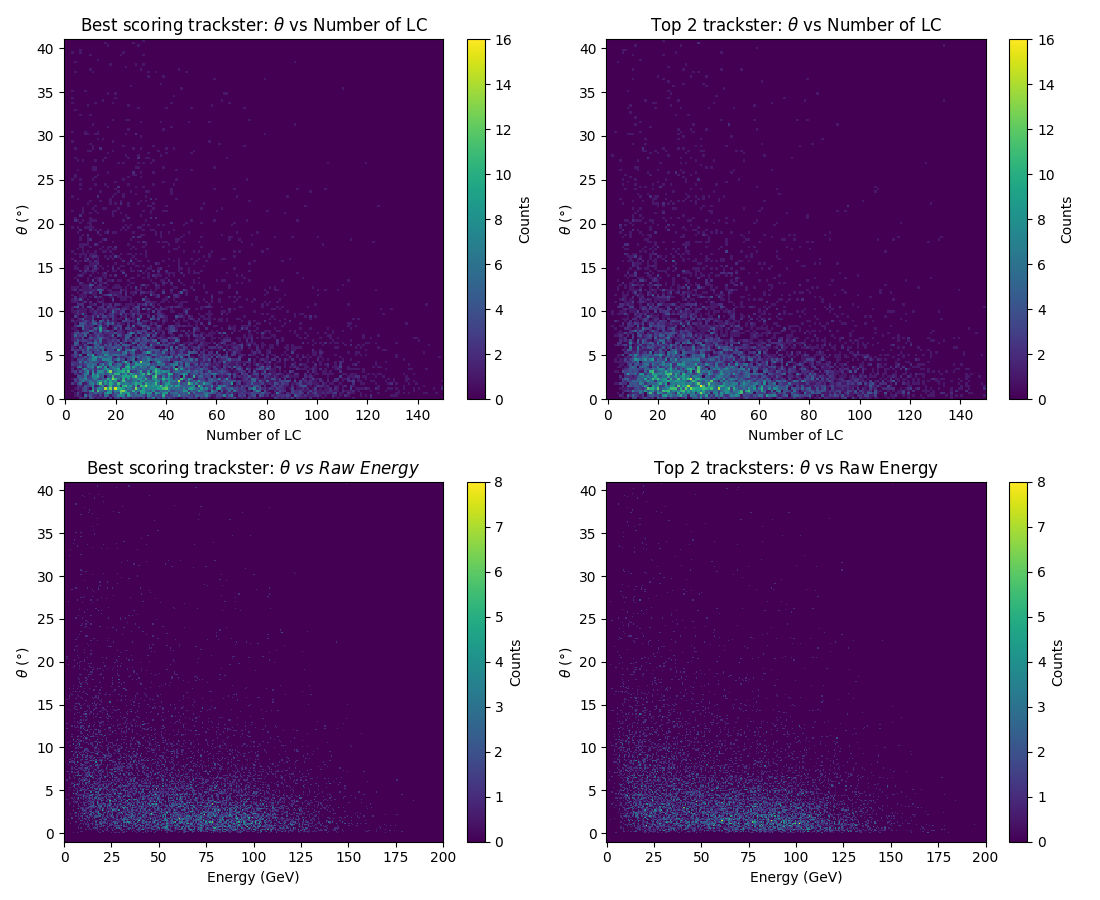

In [849]:
fig , axs = plt.subplots(2,2, figsize=(11,9))

h = axs[0,0].hist2d(ak.to_numpy(NClusters_tc_top1), theta_1, bins=150, range = ((-0.5,150),(0,41)), vmax = 16)
fig.colorbar(h[3], ax=axs[0,0], label='Counts')

axs[0,0].set_xlabel(r'Number of LC')
axs[0,0].set_ylabel(r'$\theta\ (\degree)$')
axs[0,0].set_title(r'Best scoring trackster: $ \theta$ vs Number of LC')

h = axs[0,1].hist2d(ak.to_numpy(NClusters_tc_top2), theta_2, bins=150, range = ((-0.5,150),(0,41)))
fig.colorbar(h[3], ax=axs[0,1], label='Counts')

axs[0,1].set_xlabel(r'Number of LC')
axs[0,1].set_ylabel(r'$\theta\ (\degree)$')
axs[0,1].set_title(r'Top 2 trackster: $ \theta$ vs Number of LC')


h = axs[1,0].hist2d(ak.to_numpy(baryenergy_raw_tc_top1), theta_1, bins=300, range = ((-0.1,200),((-1,41))), vmax = 8)
fig.colorbar(h[3], ax=axs[1,0], label='Counts')

axs[1,0].set_xlabel(r'Energy (GeV)')
axs[1,0].set_ylabel(r'$\theta\ (\degree)$')
axs[1,0].set_title(r'Best scoring trackster: $\theta\ vs\ Raw\ Energy$')

h = axs[1,1].hist2d(ak.to_numpy(baryenergy_raw_tc_top2), theta_2, bins=300, range = ((-0.1,200),((-1,41))))
fig.colorbar(h[3], ax=axs[1,1], label='Counts')

axs[1,1].set_xlabel(r'Energy (GeV)')
axs[1,1].set_ylabel(r'$\theta\ (\degree)$')
axs[1,1].set_title(r'Top 2 tracksters: $\theta$ vs Raw Energy')


plt.tight_layout()
plt.show()

###### theta vs Energy

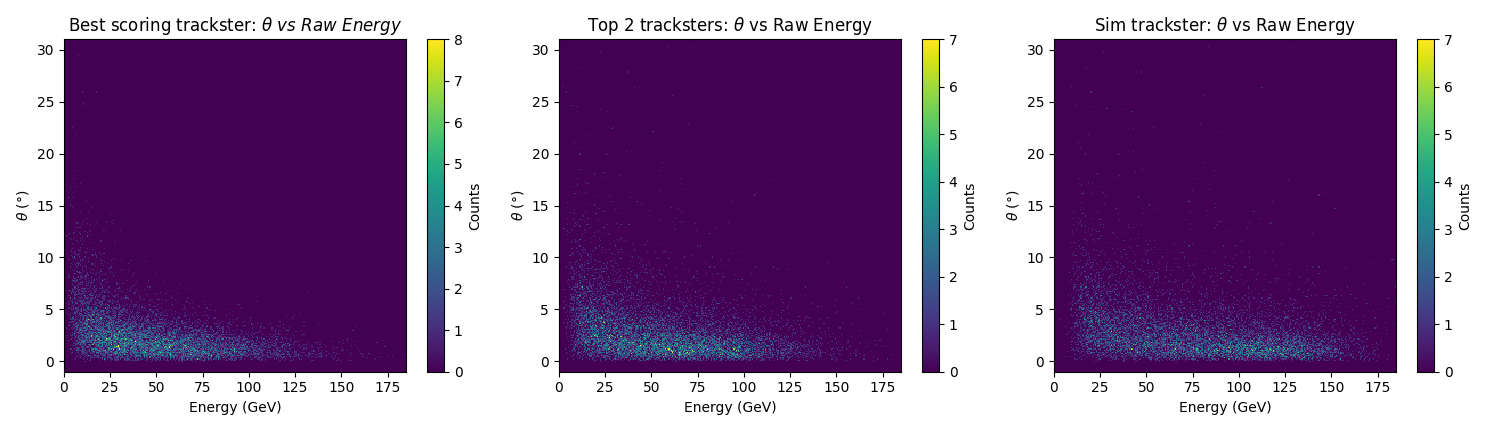

In [491]:
fig , axs = plt.subplots(1,3, figsize=(15,4.3))

h = axs[0].hist2d(ak.to_numpy(baryenergy_raw_tc3d_top1), theta_1, bins=300, range = ((0,185),((-1,31))))
fig.colorbar(h[3], ax=axs[0], label='Counts')

axs[0].set_xlabel(r'Energy (GeV)')
axs[0].set_ylabel(r'$\theta\ (\degree)$')
axs[0].set_title(r'Best scoring trackster: $\theta\ vs\ Raw\ Energy$')

h = axs[1].hist2d(ak.to_numpy(baryenergy_raw_tc3d_top2), theta_2, bins=300, range = ((0,185),((-1,31))))
fig.colorbar(h[3], ax=axs[1], label='Counts')

axs[1].set_xlabel(r'Energy (GeV)')
axs[1].set_ylabel(r'$\theta\ (\degree)$')
axs[1].set_title(r'Top 2 tracksters: $\theta$ vs Raw Energy')

h = axs[2].hist2d(ak.to_numpy(baryenergy_raw_LC1rm), theta_2, bins=300, range = ((0,185),((-1,31))))
fig.colorbar(h[3], ax=axs[2], label='Counts')

axs[2].set_xlabel(r'Energy (GeV)')
axs[2].set_ylabel(r'$\theta\ (\degree)$')
axs[2].set_title(r'Sim trackster: $\theta$ vs Raw Energy')

plt.tight_layout()
plt.show()

###### theta vs NCluster

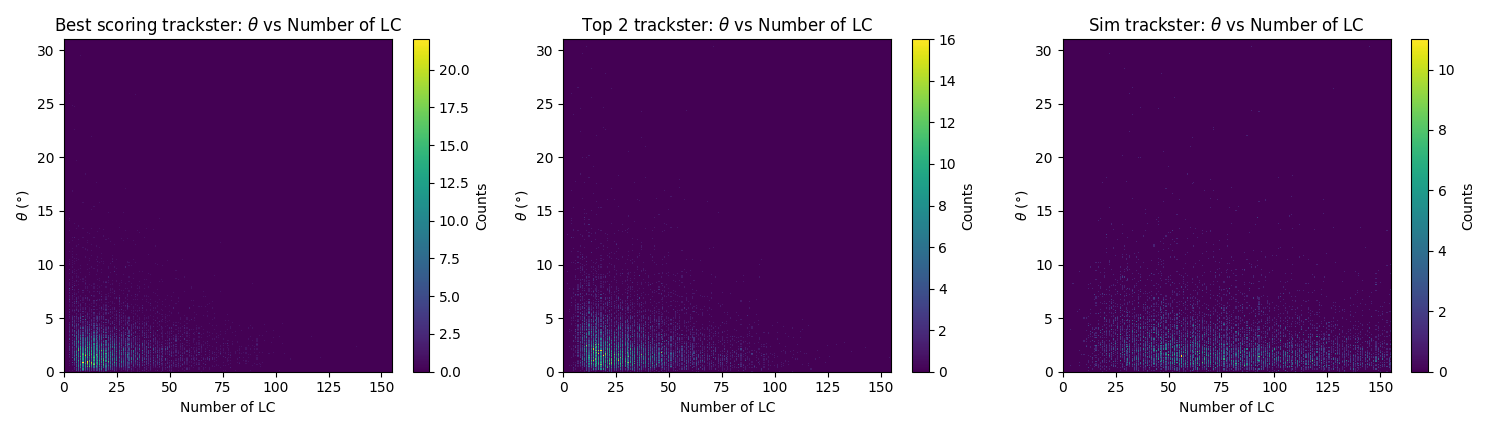

In [490]:
fig , axs = plt.subplots(1,3, figsize=(15,4.3))

h = axs[0].hist2d(ak.to_numpy(NClusters_tc3d_top1), theta_1, bins=300, range = ((0,155),(0,31)))
fig.colorbar(h[3], ax=axs[0], label='Counts')

axs[0].set_xlabel(r'Number of LC')
axs[0].set_ylabel(r'$\theta\ (\degree)$')
axs[0].set_title(r'Best scoring trackster: $ \theta$ vs Number of LC')

h = axs[1].hist2d(ak.to_numpy(NClusters_tc3d_top2), theta_2, bins=300, range = ((0,155),(0,31)))
fig.colorbar(h[3], ax=axs[1], label='Counts')

axs[1].set_xlabel(r'Number of LC')
axs[1].set_ylabel(r'$\theta\ (\degree)$')
axs[1].set_title(r'Top 2 trackster: $ \theta$ vs Number of LC')

h = axs[2].hist2d(ak.to_numpy(NClusters_LC1rm), theta_2, bins=300, range = ((0,155),(0,31)))
fig.colorbar(h[3], ax=axs[2], label='Counts')

axs[2].set_xlabel(r'Number of LC')
axs[2].set_ylabel(r'$\theta\ (\degree)$')
axs[2].set_title(r'Sim trackster: $ \theta$ vs Number of LC')

plt.tight_layout()
plt.show()

###### theta vs Explained Variance

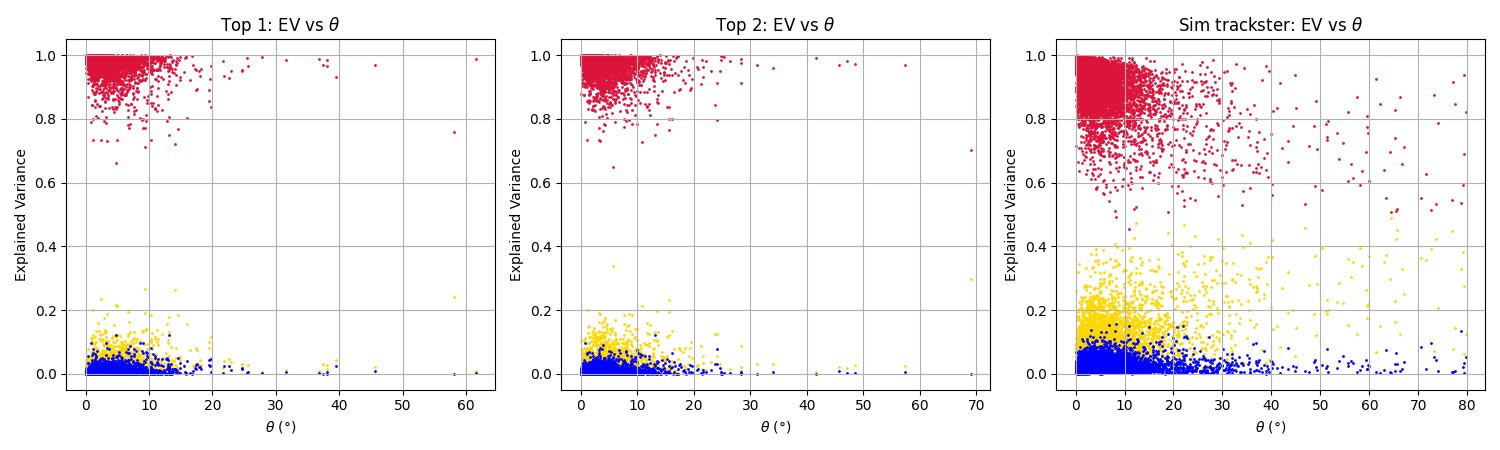

In [875]:
fig , axs = plt.subplots(1,3, figsize=(15,4.5))

above_x_mask = theta_1>80
axs[0].scatter(theta_1[~above_x_mask], EV_tc_top1[:,0][~above_x_mask] , s = 1 , color = 'crimson', label = 'EV1 ratio')
axs[0].scatter(theta_1[~above_x_mask], EV_tc_top1[:,1][~above_x_mask] , s = 1 , color = 'gold', label = 'EV2 ratio')
axs[0].scatter(theta_1[~above_x_mask], EV_tc_top1[:,2][~above_x_mask] , s = 1, color = 'blue', label = 'EV3 ratio')

axs[0].set_ylabel(r'Explained Variance')
axs[0].set_xlabel(r'$\theta\ (\degree)$')
axs[0].set_title(r'Top 1: EV vs $ \theta$') 
axs[0].grid()

above_x_mask = theta_2>80
axs[1].scatter(theta_2[~above_x_mask], EV_tc_top2[:,0][~above_x_mask] , s = 1 , color = 'crimson', label = 'EV1 ratio')
axs[1].scatter(theta_2[~above_x_mask], EV_tc_top2[:,1][~above_x_mask] , s = 1 , color = 'gold', label = 'EV2 ratio')
axs[1].scatter(theta_2[~above_x_mask], EV_tc_top2[:,2][~above_x_mask] , s = 1, color = 'blue', label = 'EV3 ratio')

axs[1].set_ylabel(r'Explained Variance')
axs[1].set_xlabel(r'$\theta\ (\degree)$')
axs[1].set_title(r'Top 2: EV vs $ \theta$') 

axs[1].grid()

above_x_mask = theta_3>80
axs[2].scatter(theta_3[~above_x_mask], EV_LC1rm[:,0][~above_x_mask] , s = 1 , color = 'crimson', label = 'EV1 ratio')
axs[2].scatter(theta_3[~above_x_mask], EV_LC1rm[:,1][~above_x_mask] , s = 1 , color = 'gold', label = 'EV2 ratio')
axs[2].scatter(theta_3[~above_x_mask], EV_LC1rm[:,2][~above_x_mask] , s = 1, color = 'blue', label = 'EV3 ratio')

axs[2].set_ylabel(r'Explained Variance')
axs[2].set_xlabel(r'$\theta\ (\degree)$')
axs[2].set_title(r'Sim trackster: EV vs $ \theta$') 

axs[2].grid()

plt.tight_layout()
plt.show()